# Seaborn: Publication-Quality Statistical Visualization

A complete one-part tutorial for **Data Science, Bioinformatics, Cancer AI, and research-oriented visualization**.

This notebook is designed as a practical lecture note. Each plotting example follows the same pattern:

1. What the plot is used for
2. Key parameters
3. Fully commented code
4. How to read the figure
5. A research-oriented use case

> **Important:** The datasets in this notebook are synthetic teaching data. They are designed to demonstrate visualization patterns and are **not real patient or gene-expression observations**.

## Official references

- Official Seaborn Example Gallery: https://seaborn.pydata.org/examples/index.html
- Official Seaborn API Reference: https://seaborn.pydata.org/api.html
- Official Seaborn documentation: https://seaborn.pydata.org/

The graph structures below are inspired by the official Seaborn gallery and adapted for learning, Bioinformatics, Cancer AI, and scientific figure preparation.

## Final function and example map

### Core / styling
- `sns.set_theme()`
- `sns.set_style()`
- `sns.set_context()`
- `sns.set_palette()`
- `sns.despine()`
- `sns.color_palette()`
- `sns.move_legend()`

### Relational plots
- `sns.scatterplot()`
- `sns.lineplot()`
- `sns.relplot()`

### Distribution plots
- `sns.histplot()`
- `sns.kdeplot()`
- `sns.ecdfplot()`
- `sns.rugplot()`
- `sns.displot()`

### Categorical plots
- `sns.barplot()`
- `sns.countplot()`
- `sns.pointplot()`
- `sns.boxplot()`
- `sns.violinplot()`
- `sns.boxenplot()`
- `sns.stripplot()`
- `sns.swarmplot()`
- `sns.catplot()`

### Regression / model diagnostics
- `sns.regplot()`
- `sns.lmplot()`
- `sns.residplot()`

### Multi-variable / grid plots
- `sns.jointplot()`
- `sns.JointGrid()`
- `sns.FacetGrid()`
- `sns.pairplot()`
- `sns.PairGrid()`

### Matrix plots
- `sns.heatmap()`
- `sns.clustermap()`

### Research-oriented figure templates
- Clinical distribution and group comparison
- Tumor volume vs molecular expression
- Survival/prediction visualization
- Prediction vs actual
- Residual diagnostics
- Gene-expression heatmap
- Differential-expression-style volcano plot
- Missing-data visualization
- Publication figure composition

> **Reference:** Official gallery and API: https://seaborn.pydata.org/examples/index.html and https://seaborn.pydata.org/api.html

In [1]:
# Import NumPy for numerical calculations and reproducible random data.
import numpy as np

# Import Pandas for tabular data manipulation.
import pandas as pd

# Import Seaborn for statistical visualization.
import seaborn as sns

# Import Matplotlib for figure-level control and publication formatting.
import matplotlib.pyplot as plt

# Import SciPy for a small number of optional statistical examples.
from scipy import stats

# Set a random seed so the synthetic teaching dataset is reproducible.
rng = np.random.default_rng(42)

# Display the versions used by this notebook.
print("Seaborn:", sns.__version__)
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Matplotlib:", plt.matplotlib.__version__)


Seaborn: 0.13.2
Pandas: 3.0.3
NumPy: 2.4.6
Matplotlib: 3.11.0


## 1. Build a synthetic clinical/research dataset

The dataset below mimics the structure of a small Cancer AI table:

- patient-level numeric variables
- categorical clinical groups
- molecular-style expression values
- survival-related values
- model predictions

This lets us practice the same figure patterns that commonly appear in biomedical ML workflows without using real patient data.

In [2]:
# Define the number of synthetic observations.
n = 240

# Create a patient identifier for each observation.
patient_ids = [f"P{i:03d}" for i in range(1, n + 1)]

# Create three synthetic clinical groups.
groups = rng.choice(["Control", "LowRisk", "HighRisk"], size=n, p=[0.25, 0.45, 0.30])

# Create synthetic age values clipped to a realistic adult range.
age = np.clip(rng.normal(55, 12, n), 20, 85).round(1)

# Make tumor volume somewhat different across groups for visualization purposes.
group_effect = pd.Series(groups).map({"Control": 2.0, "LowRisk": 8.0, "HighRisk": 18.0}).to_numpy()
tumor_volume = np.clip(rng.gamma(shape=2.2, scale=5.5, size=n) + group_effect, 0.5, 80).round(2)

# Generate a synthetic molecular expression feature correlated with tumor burden.
expression = (5 + 0.035 * tumor_volume + rng.normal(0, 0.45, n)).round(3)

# Create synthetic survival values for visualization exercises.
survival_days = np.clip(1850 - 12 * age - 7 * tumor_volume + rng.normal(0, 220, n), 90, 2400).round().astype(int)

# Define synthetic molecular subtypes.
subtype = rng.choice(["Subtype_A", "Subtype_B", "Subtype_C"], size=n, p=[0.40, 0.35, 0.25])

# Define synthetic sex labels.
sex = rng.choice(["Female", "Male"], size=n)

# Create a synthetic model prediction around the actual survival target.
predicted_survival = np.clip(survival_days + rng.normal(0, 180, n), 90, 2400).round().astype(int)

# Create a synthetic binary event variable for demonstration only.
event = rng.binomial(1, 0.55, n)

# Create a synthetic continuous risk score for ML visualization.
risk_score = np.clip(0.15 + 0.012 * tumor_volume + 0.10 * (expression - 5) + rng.normal(0, 0.10, n), 0, 1).round(3)

# Combine all synthetic variables into one DataFrame.
clinical = pd.DataFrame({
    "Patient": patient_ids,
    "Group": groups,
    "Age": age,
    "Tumor_Volume": tumor_volume,
    "Expression": expression,
    "Survival_Days": survival_days,
    "Predicted_Survival": predicted_survival,
    "Event": event,
    "Risk_Score": risk_score,
    "Subtype": subtype,
    "Sex": sex,
})

# Inspect the first few observations.
clinical.head()


,Patient,Group,Age,Tumor_Volume,Expression,Survival_Days,Predicted_Survival,Event,Risk_Score,Subtype,Sex
0,P001,HighRisk,46.3,33.66,5.858,1484,1667,1,0.719,Subtype_B,Male
1,P002,LowRisk,47.2,28.52,6.615,1515,1216,0,0.715,Subtype_B,Female
2,P003,HighRisk,29.2,28.31,5.773,1031,1030,1,0.546,Subtype_B,Female
3,P004,LowRisk,53.0,20.04,6.711,870,919,1,0.377,Subtype_C,Male
4,P005,Control,42.3,12.97,5.453,1578,1524,1,0.305,Subtype_B,Female


In [3]:
# Show the dataset structure and data types.
clinical.info()

# Select only numeric columns before calculating descriptive statistics.
# This is compatible with Pandas versions where describe() does not accept numeric_only.
clinical.select_dtypes(include="number").describe().T


<class 'pandas.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Patient             240 non-null    str    
 1   Group               240 non-null    str    
 2   Age                 240 non-null    float64
 3   Tumor_Volume        240 non-null    float64
 4   Expression          240 non-null    float64
 5   Survival_Days       240 non-null    int64  
 6   Predicted_Survival  240 non-null    int64  
 7   Event               240 non-null    int64  
 8   Risk_Score          240 non-null    float64
 9   Subtype             240 non-null    str    
 10  Sex                 240 non-null    str    
dtypes: float64(4), int64(3), str(4)
memory usage: 20.8 KB


,count,mean,std,min,25%,50%,75%,max
Age,240.0,54.902083,12.122438,24.200,46.8250,55.600,62.4000,85.000
Tumor_Volume,240.0,21.210667,10.883290,3.840,13.2000,19.805,27.6500,75.470
Expression,240.0,5.755096,0.571150,4.221,5.4050,5.696,6.1420,7.404
Survival_Days,240.0,1043.616667,271.533478,393.000,860.7500,1041.500,1218.7500,1667.000
Predicted_Survival,240.0,1012.016667,343.287527,118.000,767.0000,1037.500,1246.7500,1817.000
Event,240.0,0.591667,0.492553,0.000,0.0000,1.000,1.0000,1.000
Risk_Score,240.0,0.482304,0.206529,0.058,0.3205,0.487,0.6025,1.000


## 2. Figure styling: the foundation of publication-quality plots

A good scientific figure is not only about the graph type. It also depends on:

- readable typography
- sensible figure dimensions
- clean axes
- intentional color selection
- appropriate labels
- consistent styling

The functions used here are `set_theme()`, `set_style()`, `set_context()`, `set_palette()`, `despine()`, and Matplotlib figure controls.

Official reference: https://seaborn.pydata.org/tutorial/aesthetics.html

### Styling toolbox: `set_style()`, `set_context()`, `set_palette()`, `color_palette()`, `move_legend()`

These functions control the visual language of a project. Keep styling consistent across a manuscript rather than choosing a new style for every figure.

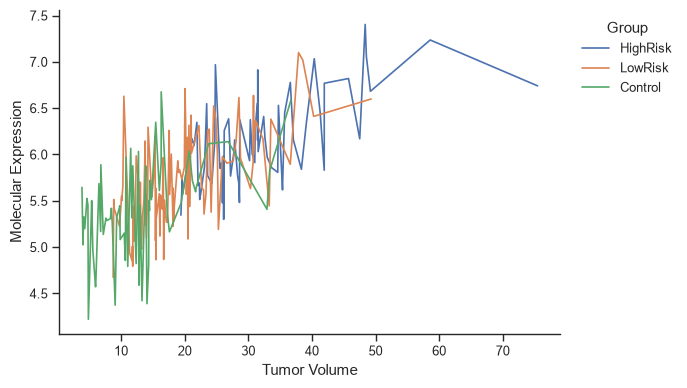

In [4]:
# Set the background and spine treatment used by Seaborn.
sns.set_style("ticks")

# Set the relative scale of text and plot elements for a paper.
sns.set_context("paper", font_scale=1.1)

# Set a reusable categorical color cycle.
sns.set_palette("deep")

# Generate a palette object that can be reused in custom plotting code.
palette = sns.color_palette("deep", 3)

# Create a simple plot with a legend so we can demonstrate legend placement.
fig, ax = plt.subplots(figsize=(7, 4))

# Plot one line per synthetic clinical group.
sns.lineplot(
    data=clinical,
    x="Tumor_Volume",
    y="Expression",
    hue="Group",
    errorbar=None,
    ax=ax
)

# Move the legend outside the main plotting area.
sns.move_legend(
    ax,
    "upper left",
    bbox_to_anchor=(1.02, 1),
    frameon=False,
    title="Group"
)

# Label both axes explicitly.
ax.set_xlabel("Tumor Volume")
ax.set_ylabel("Molecular Expression")

# Remove unnecessary borders.
sns.despine(ax=ax)

# Tighten the layout while leaving room for the external legend.
fig.tight_layout()

# Display the styled figure.
plt.show()


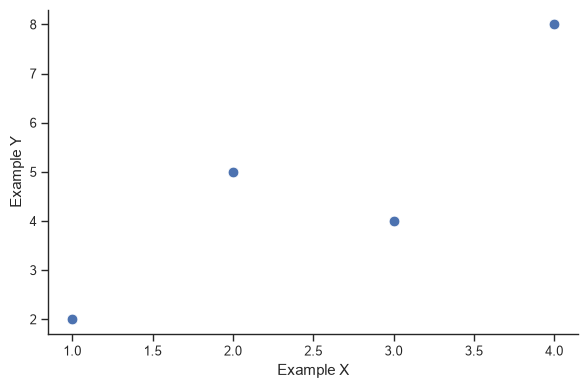

In [5]:
# Set a clean publication-oriented theme.
# "ticks" keeps useful axis ticks while removing the heavy top and right borders.
# "paper" scales text and elements for scientific figure sizes.
# font_scale gives us a small global typography adjustment.
sns.set_theme(style="ticks", context="paper", font_scale=1.1)

# Set a muted categorical palette for consistent group colors.
sns.set_palette("deep")

# Create a Matplotlib figure and axes.
fig, ax = plt.subplots(figsize=(6, 4))

# Create a simple scatter plot as a styling demonstration.
# x and y provide the coordinates of the observations.
# s controls marker size.
# ax specifies the Matplotlib axes receiving the plot.
sns.scatterplot(
    x=[1, 2, 3, 4],
    y=[2, 5, 4, 8],
    s=60,
    ax=ax
)

# Add explicit axis labels for a paper-ready figure.
ax.set_xlabel("Example X")
ax.set_ylabel("Example Y")

# Remove the top and right spines for a cleaner scientific appearance.
sns.despine(ax=ax)

# Adjust spacing so labels are not clipped.
plt.tight_layout()

# Display the finished figure.
plt.show()


### How to read this plot

This is mainly a **style template**. The important lesson is that scientific visualization begins with consistent figure dimensions, labels, typography, and axis cleanup before more advanced plotting is added.

## 3. Scatter plots — `scatterplot()`

Use scatter plots when both the x-axis and y-axis represent individual observations. This is especially useful for:

- feature relationships
- biomarker associations
- model error inspection
- exploratory clinical analysis

Important parameters:

- `x`, `y` — variables to plot
- `hue` — color observations by a category
- `style` — marker shape by a category
- `size` — marker size by a numeric/categorical variable
- `alpha` — transparency
- `palette` — color mapping
- `s` — fixed marker size

Official gallery: https://seaborn.pydata.org/examples/scatterplot.html

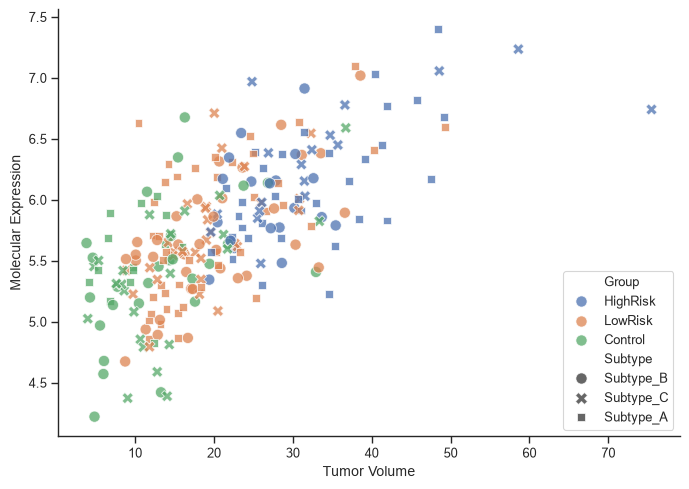

In [6]:
# Set a clean research-oriented theme for the figure.
sns.set_theme(style="ticks", context="paper", font_scale=1.05)

# Create the figure and axes.
fig, ax = plt.subplots(figsize=(7, 5))

# Plot tumor volume against molecular expression.
# hue separates the clinical groups using color.
# style changes marker shape by molecular subtype.
# alpha makes dense regions easier to inspect.
# s controls the marker size.
sns.scatterplot(
    data=clinical,
    x="Tumor_Volume",
    y="Expression",
    hue="Group",
    style="Subtype",
    s=65,
    alpha=0.75,
    ax=ax
)

# Add explicit scientific axis labels.
ax.set_xlabel("Tumor Volume")
ax.set_ylabel("Molecular Expression")

# Remove the top and right spines.
sns.despine(ax=ax)

# Tighten the layout before displaying the figure.
plt.tight_layout()

# Display the plot.
plt.show()


### How to read the scatter plot

Each point is one synthetic observation. Color represents the clinical group, while marker shape represents subtype. Patterns, clusters, outliers, or possible relationships can then be investigated statistically.

## 4. Line plots — `lineplot()`

Line plots are useful when observations have an ordered x-axis, especially time or another continuous sequence.

Typical biomedical uses:

- longitudinal measurements
- training curves
- time-series biomarkers
- average trajectories across groups

Official gallery: https://seaborn.pydata.org/examples/lineplot.html

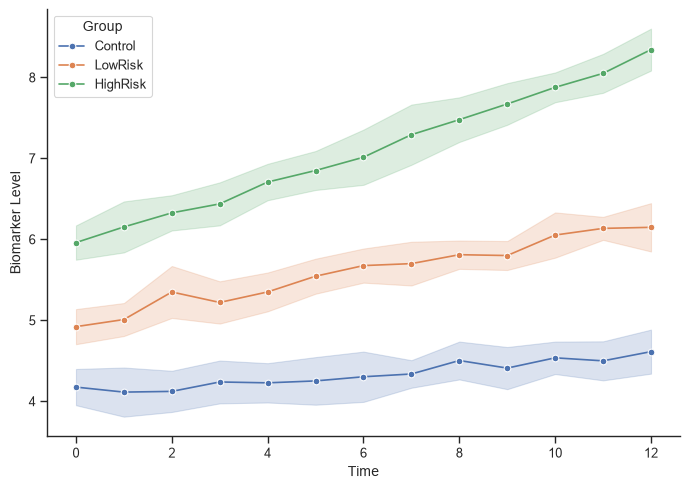

In [7]:
# Create a synthetic longitudinal dataset for three groups.
time = np.arange(0, 13)
trajectory_rows = []

# Generate repeated measurements for several synthetic subjects per group.
for group in ["Control", "LowRisk", "HighRisk"]:
    for subject in range(12):
        baseline = {"Control": 4.0, "LowRisk": 5.0, "HighRisk": 6.0}[group]
        slope = {"Control": 0.05, "LowRisk": 0.10, "HighRisk": 0.18}[group]
        values = baseline + slope * time + rng.normal(0, 0.25, len(time))
        for t, value in zip(time, values):
            trajectory_rows.append((group, subject, t, value))

# Convert the long-form rows into a DataFrame.
trajectory = pd.DataFrame(trajectory_rows, columns=["Group", "Subject", "Time", "Biomarker"])

# Create the figure and axes.
fig, ax = plt.subplots(figsize=(7, 5))

# Plot the mean biomarker trajectory for each group.
# hue creates one line per group.
# marker makes time-point locations easier to inspect.
# errorbar="sd" adds variability around the estimated line.
sns.lineplot(
    data=trajectory,
    x="Time",
    y="Biomarker",
    hue="Group",
    marker="o",
    errorbar="sd",
    ax=ax
)

# Label the axes with scientifically meaningful descriptions.
ax.set_xlabel("Time")
ax.set_ylabel("Biomarker Level")

# Remove unnecessary borders.
sns.despine(ax=ax)

# Prevent label overlap.
plt.tight_layout()

# Display the figure.
plt.show()


### How to read the line plot

The center line represents the estimated group trajectory. The shaded region summarizes variability based on the selected `errorbar` method. For formal scientific conclusions, the uncertainty method and analysis design must match the study protocol.

## 4.1. Figure-level relational plots — `relplot()`

`relplot()` provides a figure-level interface for scatter and line plots and makes faceting straightforward.

Official gallery: https://seaborn.pydata.org/examples/index.html

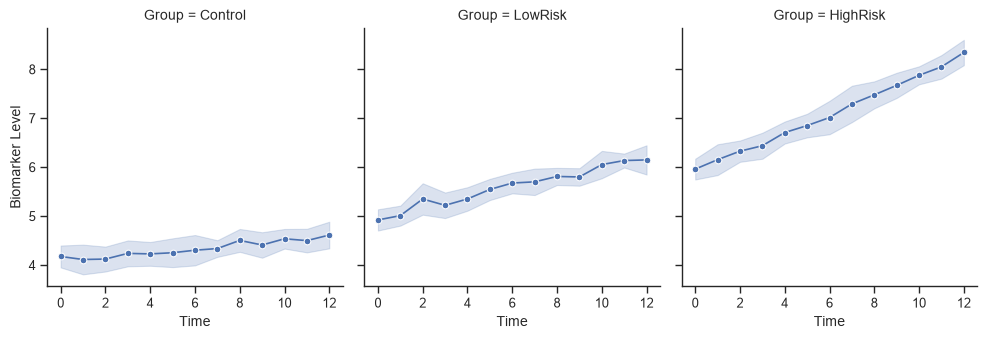

In [8]:
# Create a faceted relational plot using the same long-form trajectory data.
# kind="line" selects the lineplot engine.
# col="Group" creates one panel per clinical group.
g = sns.relplot(
    data=trajectory,
    x="Time",
    y="Biomarker",
    col="Group",
    kind="line",
    errorbar="sd",
    marker="o",
    height=3.5,
    aspect=0.95
)

# Set shared axis labels for the complete figure.
g.set_axis_labels("Time", "Biomarker Level")

# Apply a compact layout.
g.figure.tight_layout()

# Display the faceted relational figure.
plt.show()


## 5. Distribution plots — `histplot()`, `kdeplot()`, `ecdfplot()`, `rugplot()`, `displot()`

Distribution plots answer a different question than scatter plots: **How are the observations distributed?**

Useful choices:

- `histplot()` — histogram of values
- `kdeplot()` — smooth density estimate
- `ecdfplot()` — cumulative distribution
- `rugplot()` — individual value marks on an axis
- `displot()` — figure-level distribution interface

Official API: https://seaborn.pydata.org/api.html

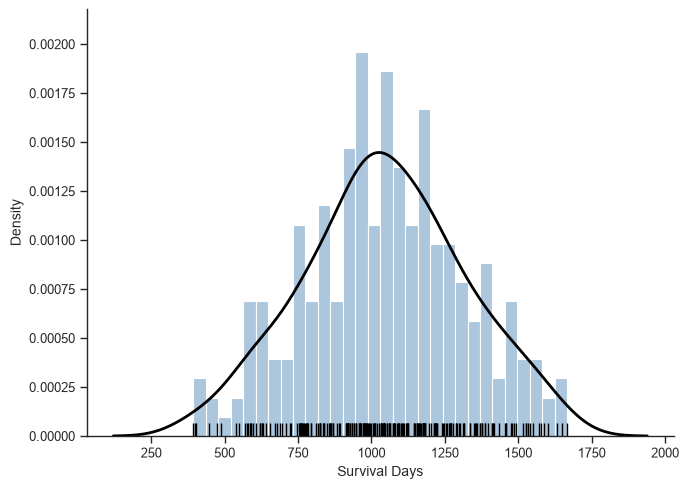

In [9]:
# Create one figure with a histogram and a KDE density estimate.
fig, ax = plt.subplots(figsize=(7, 5))

# Draw the histogram of survival values.
# bins controls the number of intervals used to summarize the data.
# stat="density" puts the histogram on a density scale.
sns.histplot(
    data=clinical,
    x="Survival_Days",
    bins=30,
    stat="density",
    alpha=0.45,
    color="steelblue",
    ax=ax
)

# Overlay a kernel density estimate of the same variable.
# This provides a smooth approximation of the observed distribution.
sns.kdeplot(
    data=clinical,
    x="Survival_Days",
    linewidth=2,
    color="black",
    ax=ax
)

# Add small marks for individual observations along the axis.
sns.rugplot(
    data=clinical,
    x="Survival_Days",
    height=0.03,
    color="black",
    ax=ax
)

# Label the x-axis and y-axis.
ax.set_xlabel("Survival Days")
ax.set_ylabel("Density")

# Remove unnecessary plot borders.
sns.despine(ax=ax)

# Adjust the layout.
plt.tight_layout()

# Display the figure.
plt.show()


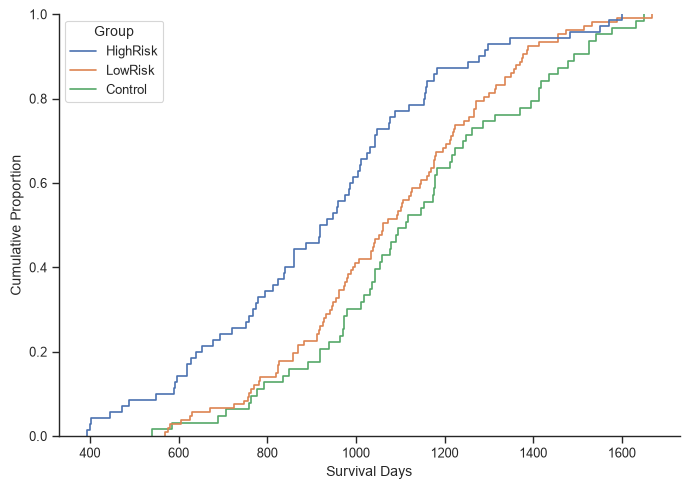

In [10]:
# Create a new figure for the empirical cumulative distribution function.
fig, ax = plt.subplots(figsize=(7, 5))

# Plot the ECDF of survival values by clinical group.
# The ECDF shows the fraction of observations at or below each x value.
sns.ecdfplot(
    data=clinical,
    x="Survival_Days",
    hue="Group",
    ax=ax
)

# Add axis labels.
ax.set_xlabel("Survival Days")
ax.set_ylabel("Cumulative Proportion")

# Clean the frame.
sns.despine(ax=ax)

# Apply a compact layout.
plt.tight_layout()

# Display the figure.
plt.show()


### How to read distribution plots

Histograms emphasize bins, KDE emphasizes shape, and ECDF emphasizes cumulative thresholds. ECDF plots are particularly useful when you want to compare the entire distribution without choosing histogram bin widths.

### Figure-level distributions — `displot()`

`displot()` provides a figure-level interface for several distribution plot types. It is useful when the same distribution view should be repeated across groups or facets.

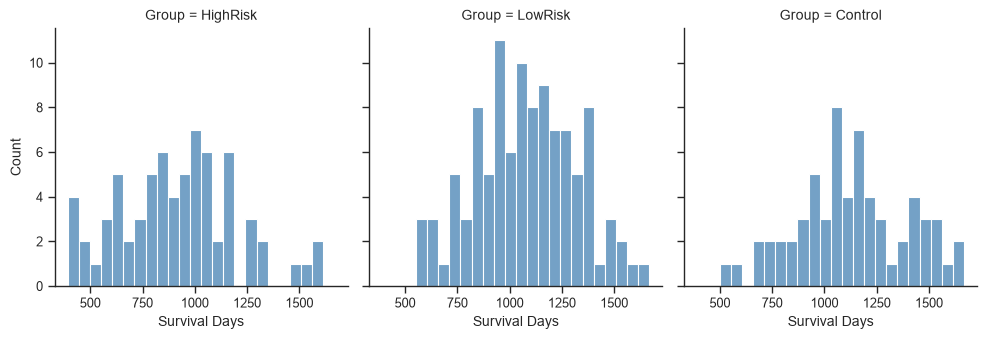

In [11]:
# Create a figure-level histogram split by clinical group.
# kind="hist" selects the histogram representation.
# col="Group" creates one panel for each group.
g = sns.displot(
    data=clinical,
    x="Survival_Days",
    col="Group",
    kind="hist",
    bins=24,
    color="steelblue",
    height=3.5,
    aspect=0.95
)

# Add readable shared axis labels.
g.set_axis_labels("Survival Days", "Count")

# Adjust the complete figure layout.
g.figure.tight_layout()

# Display the distribution figure.
plt.show()


## 6. Categorical plots — `barplot()`, `countplot()`, `pointplot()`

Categorical plots are useful when one axis contains categories such as:

- treatment/group
- molecular subtype
- sex
- risk class

`barplot()` and `pointplot()` estimate a numeric summary, while `countplot()` shows how many observations exist in each category.

Official gallery examples include these models: https://seaborn.pydata.org/examples/index.html

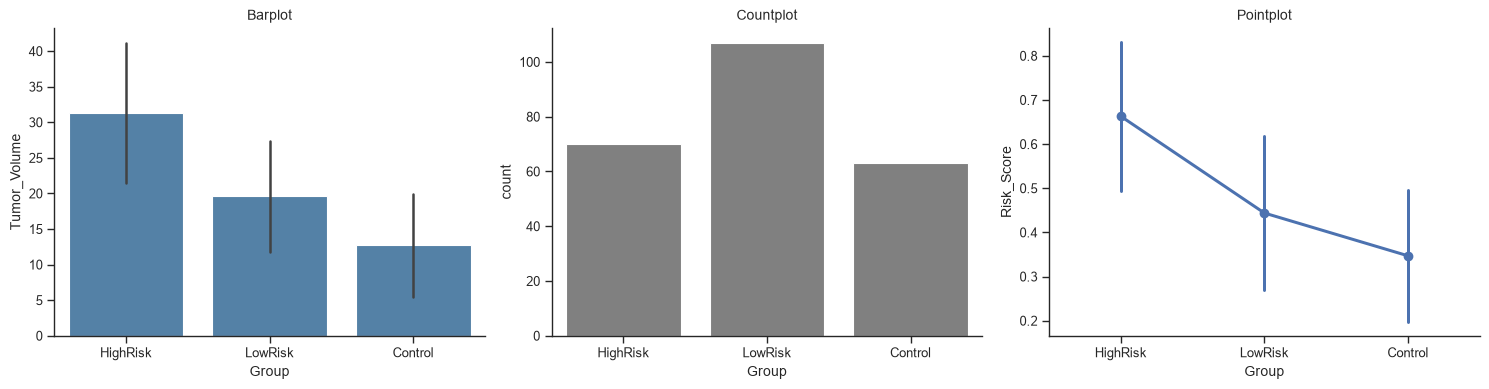

In [12]:
# Create a three-panel categorical overview.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Show the mean tumor volume for each clinical group.
# errorbar="sd" adds the standard deviation as an uncertainty display.
sns.barplot(
    data=clinical,
    x="Group",
    y="Tumor_Volume",
    errorbar="sd",
    color="steelblue",
    ax=axes[0]
)

# Show the number of observations in each group.
sns.countplot(
    data=clinical,
    x="Group",
    color="grey",
    ax=axes[1]
)

# Show group-level estimates as points connected by lines.
sns.pointplot(
    data=clinical,
    x="Group",
    y="Risk_Score",
    errorbar="sd",
    ax=axes[2]
)

# Add a descriptive title to each panel.
axes[0].set_title("Barplot")
axes[1].set_title("Countplot")
axes[2].set_title("Pointplot")

# Remove unnecessary borders from all axes.
for ax in axes:
    sns.despine(ax=ax)

# Keep all three panels aligned and readable.
plt.tight_layout()

# Display the figure.
plt.show()


### How to read categorical summary plots

A bar or point estimate summarizes a group, but it can hide the underlying observations. For research reporting, pair summary plots with raw observations when sample size and overplotting allow it.

## 7. Box plots — `boxplot()`

A box plot summarizes a distribution using quartiles and whiskers and is particularly useful for comparing groups.

Core parameters:

- `x`, `y` — variables
- `hue` — nested grouping
- `order` — explicit category order
- `whis` — whisker definition
- `width` — box width
- `showfliers` — control outlier markers

Official gallery model: **Horizontal boxplot with observations**
https://seaborn.pydata.org/examples/horizontal_boxplot.html

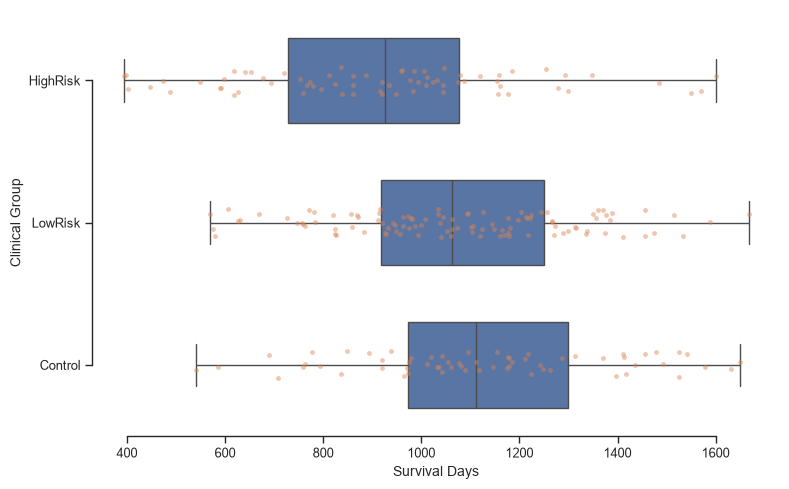

In [13]:
# Create the figure and axes.
fig, ax = plt.subplots(figsize=(8, 5))

# Draw horizontal boxplots of survival across the clinical groups.
# whis=(0, 100) extends whiskers across the full data range for a teaching example.
# orient="h" requests a horizontal orientation.
sns.boxplot(
    data=clinical,
    x="Survival_Days",
    y="Group",
    whis=(0, 100),
    width=0.6,
    orient="h",
    ax=ax
)

# Overlay each individual observation.
# This follows the official Seaborn gallery pattern of combining a boxplot with stripplot.
sns.stripplot(
    data=clinical,
    x="Survival_Days",
    y="Group",
    size=3.5,
    alpha=0.45,
    ax=ax
)

# Label the axes.
ax.set_xlabel("Survival Days")
ax.set_ylabel("Clinical Group")

# Remove the top and right borders.
sns.despine(ax=ax, trim=True)

# Tighten the layout.
plt.tight_layout()

# Display the final figure.
plt.show()


### How to read a box plot

The box shows the interquartile range, the center line marks the median, and whiskers summarize the selected range. Adding individual observations makes sample size and distribution shape easier to inspect.

## 8. Violin plots — `violinplot()`

A violin plot combines distribution shape with category comparison. It is based on a kernel density estimate and can show a compact view of multimodal distributions.

Official gallery model: https://seaborn.pydata.org/examples/simple_violinplots.html

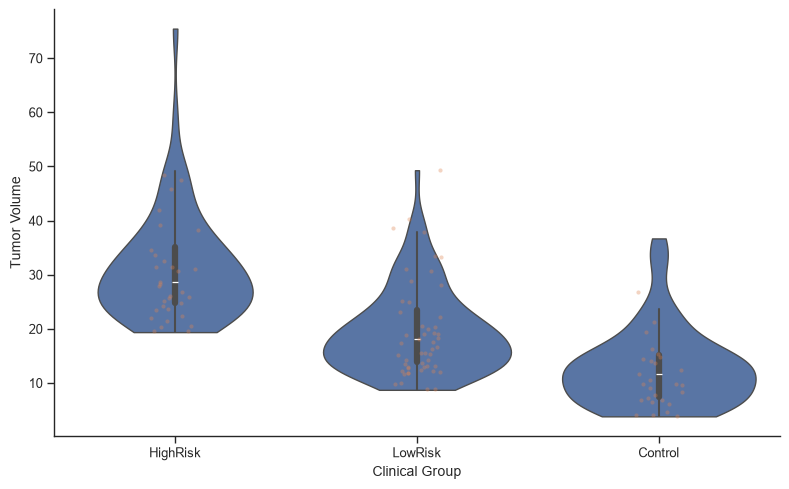

In [14]:
# Create the figure and axes.
fig, ax = plt.subplots(figsize=(8, 5))

# Draw a violin plot for tumor volume across clinical groups.
# inner="box" places compact box statistics inside each violin.
# cut=0 prevents the KDE from extending beyond the observed data range.
sns.violinplot(
    data=clinical,
    x="Group",
    y="Tumor_Volume",
    inner="box",
    cut=0,
    ax=ax
)

# Overlay a small set of raw observations.
sns.stripplot(
    data=clinical.sample(110, random_state=42),
    x="Group",
    y="Tumor_Volume",
    size=3,
    alpha=0.35,
    ax=ax
)

# Add axis labels.
ax.set_xlabel("Clinical Group")
ax.set_ylabel("Tumor Volume")

# Remove unnecessary borders.
sns.despine(ax=ax)

# Adjust the layout.
plt.tight_layout()

# Display the figure.
plt.show()


### How to read a violin plot

Wider sections indicate greater estimated density. A violin can reveal skewness or multiple peaks that a box plot may hide. Because KDE bandwidth affects the shape, the figure should not be interpreted as direct raw-data frequency without context.

## 9. Large-data distributions — `boxenplot()`

`boxenplot()` is designed to show more distribution detail than a traditional box plot, especially when the dataset is large.

Official API: https://seaborn.pydata.org/api.html

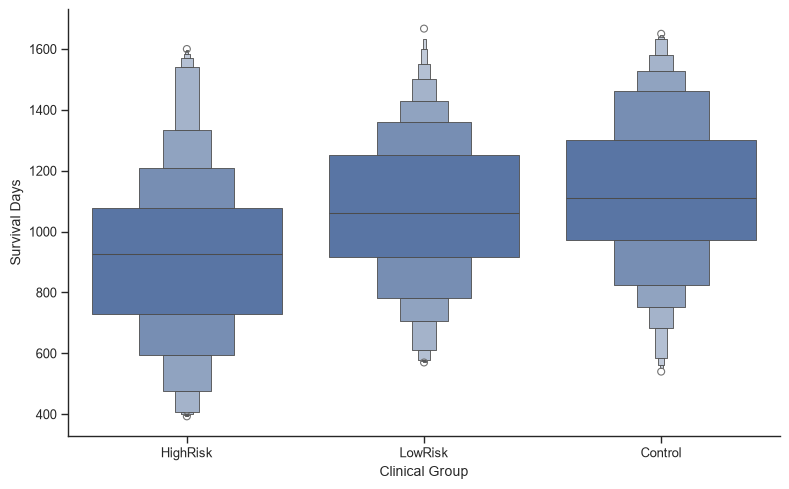

In [15]:
# Create the figure and axes.
fig, ax = plt.subplots(figsize=(8, 5))

# Draw an enhanced box plot for the synthetic survival distributions.
# k_depth controls how many letter-value boxes are shown.
sns.boxenplot(
    data=clinical,
    x="Group",
    y="Survival_Days",
    k_depth="proportion",
    ax=ax
)

# Add axis labels.
ax.set_xlabel("Clinical Group")
ax.set_ylabel("Survival Days")

# Clean the frame.
sns.despine(ax=ax)

# Tighten the layout.
plt.tight_layout()

# Display the figure.
plt.show()


### How to read a boxen plot

The additional nested boxes provide more information about the distribution tails than a standard box plot. This makes the plot useful for large cohorts where tail behavior matters.

## 10. Raw observations — `stripplot()` and `swarmplot()`

These plots are useful when the individual observations matter.

- `stripplot()` jitters points to reduce overlap.
- `swarmplot()` actively arranges points to avoid overlap.

For large datasets, `swarmplot()` can become computationally expensive, so it should be used selectively.

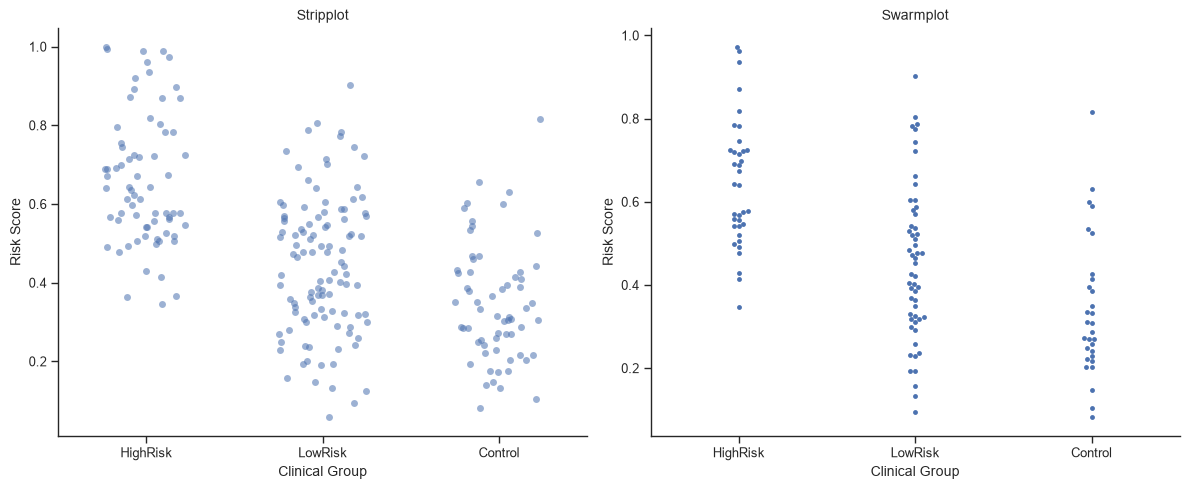

In [16]:
# Create two side-by-side axes for direct comparison.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Draw a jittered strip plot for individual observations.
sns.stripplot(
    data=clinical,
    x="Group",
    y="Risk_Score",
    jitter=0.25,
    alpha=0.55,
    ax=axes[0]
)

# Draw a swarm plot that positions points to minimize overlap.
sns.swarmplot(
    data=clinical.sample(120, random_state=42),
    x="Group",
    y="Risk_Score",
    size=3.5,
    ax=axes[1]
)

# Add titles to identify the two plot types.
axes[0].set_title("Stripplot")
axes[1].set_title("Swarmplot")

# Label the axes.
axes[0].set_xlabel("Clinical Group")
axes[0].set_ylabel("Risk Score")
axes[1].set_xlabel("Clinical Group")
axes[1].set_ylabel("Risk Score")

# Remove unnecessary borders.
for ax in axes:
    sns.despine(ax=ax)

# Adjust spacing between panels.
plt.tight_layout()

# Display the comparison.
plt.show()


## 11. Figure-level categorical plots — `catplot()`

`catplot()` combines categorical plotting with a `FacetGrid`. It is useful when you want the same categorical comparison repeated across another variable.

Official gallery: https://seaborn.pydata.org/examples/index.html

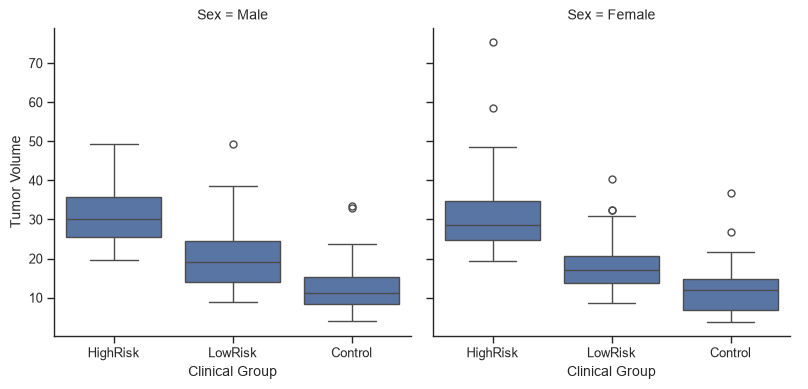

In [17]:
# Create a figure-level categorical plot split into one panel per sex.
# kind="box" selects the underlying categorical plot type.
# col="Sex" creates one facet for each sex category.
g = sns.catplot(
    data=clinical,
    x="Group",
    y="Tumor_Volume",
    col="Sex",
    kind="box",
    height=4,
    aspect=1.0
)

# Set a clear shared y-axis label through the figure-level object.
g.set_axis_labels("Clinical Group", "Tumor Volume")

# Remove the top and right spines on each facet.
for ax in g.axes.flat:
    sns.despine(ax=ax)

# Adjust the final spacing.
g.figure.tight_layout()

# Display the figure.
plt.show()


### How to read a faceted categorical plot

Faceting lets you compare the same relationship under different subgroup conditions. In research, this can expose patterns that disappear when all observations are pooled.

## 12. Regression plots — `regplot()`, `lmplot()`, `residplot()`

Regression visualizations are useful for showing an observed relationship alongside a fitted model.

- `regplot()` works directly with an axes object.
- `lmplot()` combines regression with faceting.
- `residplot()` visualizes residual structure.

Official API: https://seaborn.pydata.org/api.html

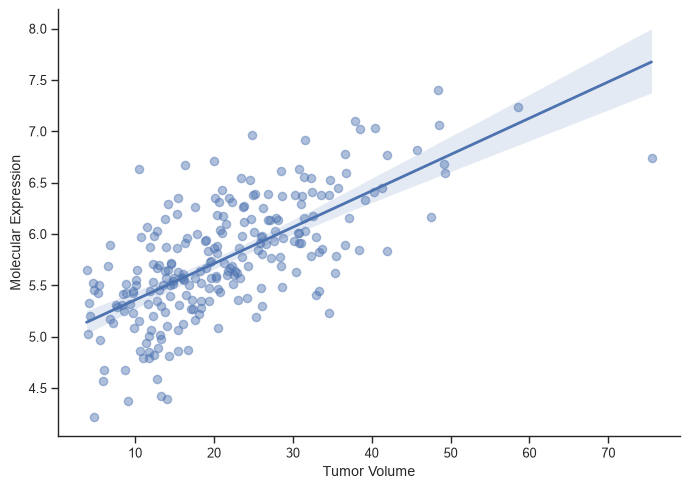

In [18]:
# Create a Matplotlib figure and axes.
fig, ax = plt.subplots(figsize=(7, 5))

# Plot the observed relationship between tumor volume and expression.
# Seaborn adds a fitted linear regression line and confidence interval by default.
sns.regplot(
    data=clinical,
    x="Tumor_Volume",
    y="Expression",
    scatter_kws={"s": 35, "alpha": 0.45},
    line_kws={"linewidth": 2},
    ax=ax
)

# Label the axes.
ax.set_xlabel("Tumor Volume")
ax.set_ylabel("Molecular Expression")

# Clean the frame.
sns.despine(ax=ax)

# Tighten the layout.
plt.tight_layout()

# Display the regression figure.
plt.show()


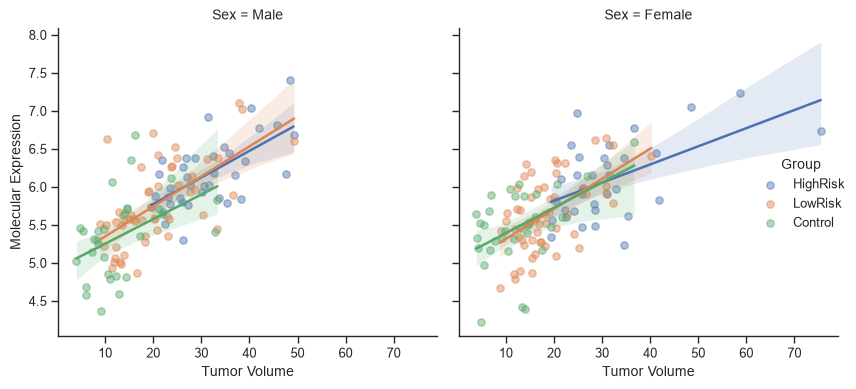

In [19]:
# Create a faceted regression model by clinical group.
# hue colors the groups, while col creates separate panels.
g = sns.lmplot(
    data=clinical,
    x="Tumor_Volume",
    y="Expression",
    hue="Group",
    col="Sex",
    height=4,
    aspect=0.95,
    scatter_kws={"s": 28, "alpha": 0.45}
)

# Add readable axis labels to all panels.
g.set_axis_labels("Tumor Volume", "Molecular Expression")

# Apply a compact layout.
g.figure.tight_layout()

# Display the figure.
plt.show()


RuntimeError: `lowess=True` requires statsmodels, an optional dependency, to be installed.

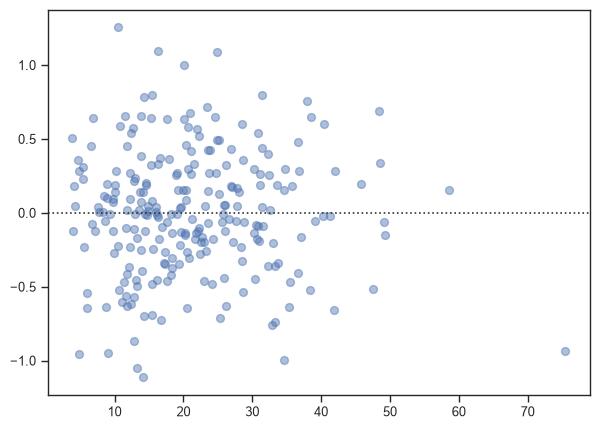

In [20]:
# Create a residual diagnostic figure.
fig, ax = plt.subplots(figsize=(7, 5))

# Plot residuals from the relationship between tumor volume and expression.
# A good residual plot should be inspected for systematic structure.
sns.residplot(
    data=clinical,
    x="Tumor_Volume",
    y="Expression",
    lowess=True,
    scatter_kws={"s": 32, "alpha": 0.45},
    line_kws={"linewidth": 2},
    ax=ax
)

# Add a reference zero line because residuals are centered around zero.
ax.axhline(0, linestyle="--", linewidth=1)

# Label the axes.
ax.set_xlabel("Tumor Volume")
ax.set_ylabel("Residual")

# Remove unnecessary borders.
sns.despine(ax=ax)

# Tighten the layout.
plt.tight_layout()

# Display the figure.
plt.show()


### How to read regression figures

The regression line summarizes the fitted relationship; the residual plot is a diagnostic for model structure. A visible pattern in residuals can indicate nonlinearity, heteroscedasticity, or another modeling issue. Visualization does not replace formal model diagnostics.

## 13. Distribution + relationship together — `jointplot()`

`jointplot()` combines a bivariate relationship with the marginal distributions of both variables.

Official gallery: https://seaborn.pydata.org/examples/index.html

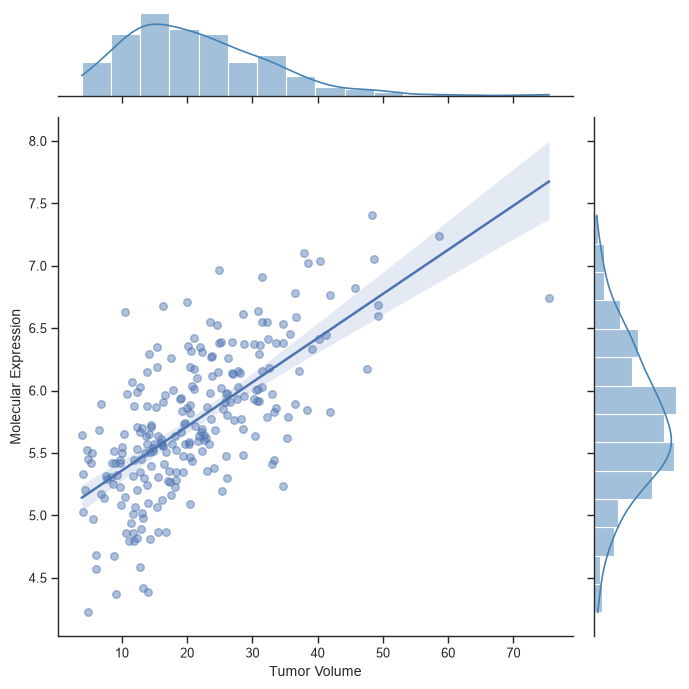

In [21]:
# Create a joint plot of tumor volume and molecular expression.
# kind="reg" adds a regression model to the central scatter plot.
g = sns.jointplot(
    data=clinical,
    x="Tumor_Volume",
    y="Expression",
    kind="reg",
    height=7,
    scatter_kws={"s": 30, "alpha": 0.45},
    marginal_kws={"color": "steelblue"}
)

# Give the central plot explicit axis labels.
g.set_axis_labels("Tumor Volume", "Molecular Expression")

# Apply a compact layout to the complete figure.
g.figure.tight_layout()

# Display the joint figure.
plt.show()


### `JointGrid()` for custom joint figures

`JointGrid` gives lower-level control than `jointplot()`. It is useful when the central plot and the two marginal plots need to use different plotting functions.

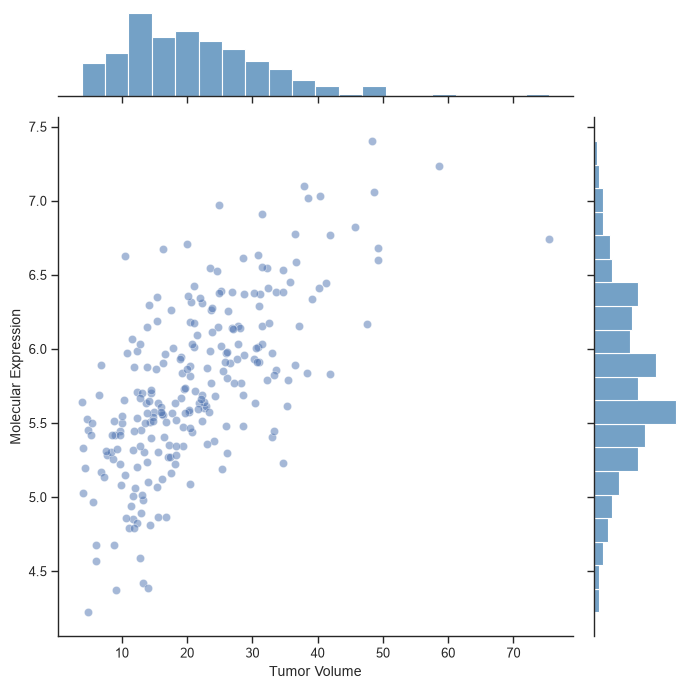

In [22]:
# Create a custom joint-grid layout.
g = sns.JointGrid(data=clinical, x="Tumor_Volume", y="Expression", height=7)

# Draw the main scatter plot in the center.
g.plot_joint(sns.scatterplot, s=35, alpha=0.5)

# Draw a histogram for the x-axis distribution.
g.plot_marginals(sns.histplot, bins=20, color="steelblue")

# Apply readable axis labels.
g.set_axis_labels("Tumor Volume", "Molecular Expression")

# Adjust spacing.
g.figure.tight_layout()

# Display the custom joint figure.
plt.show()


## 14. Multi-variable exploration — `pairplot()`

`pairplot()` creates a matrix of pairwise relationships across several numeric variables.

Use it for exploration rather than final publication figures. A large pairplot can become visually crowded.

Official gallery: https://seaborn.pydata.org/examples/pair_grid_with_kde.html and https://seaborn.pydata.org/api.html

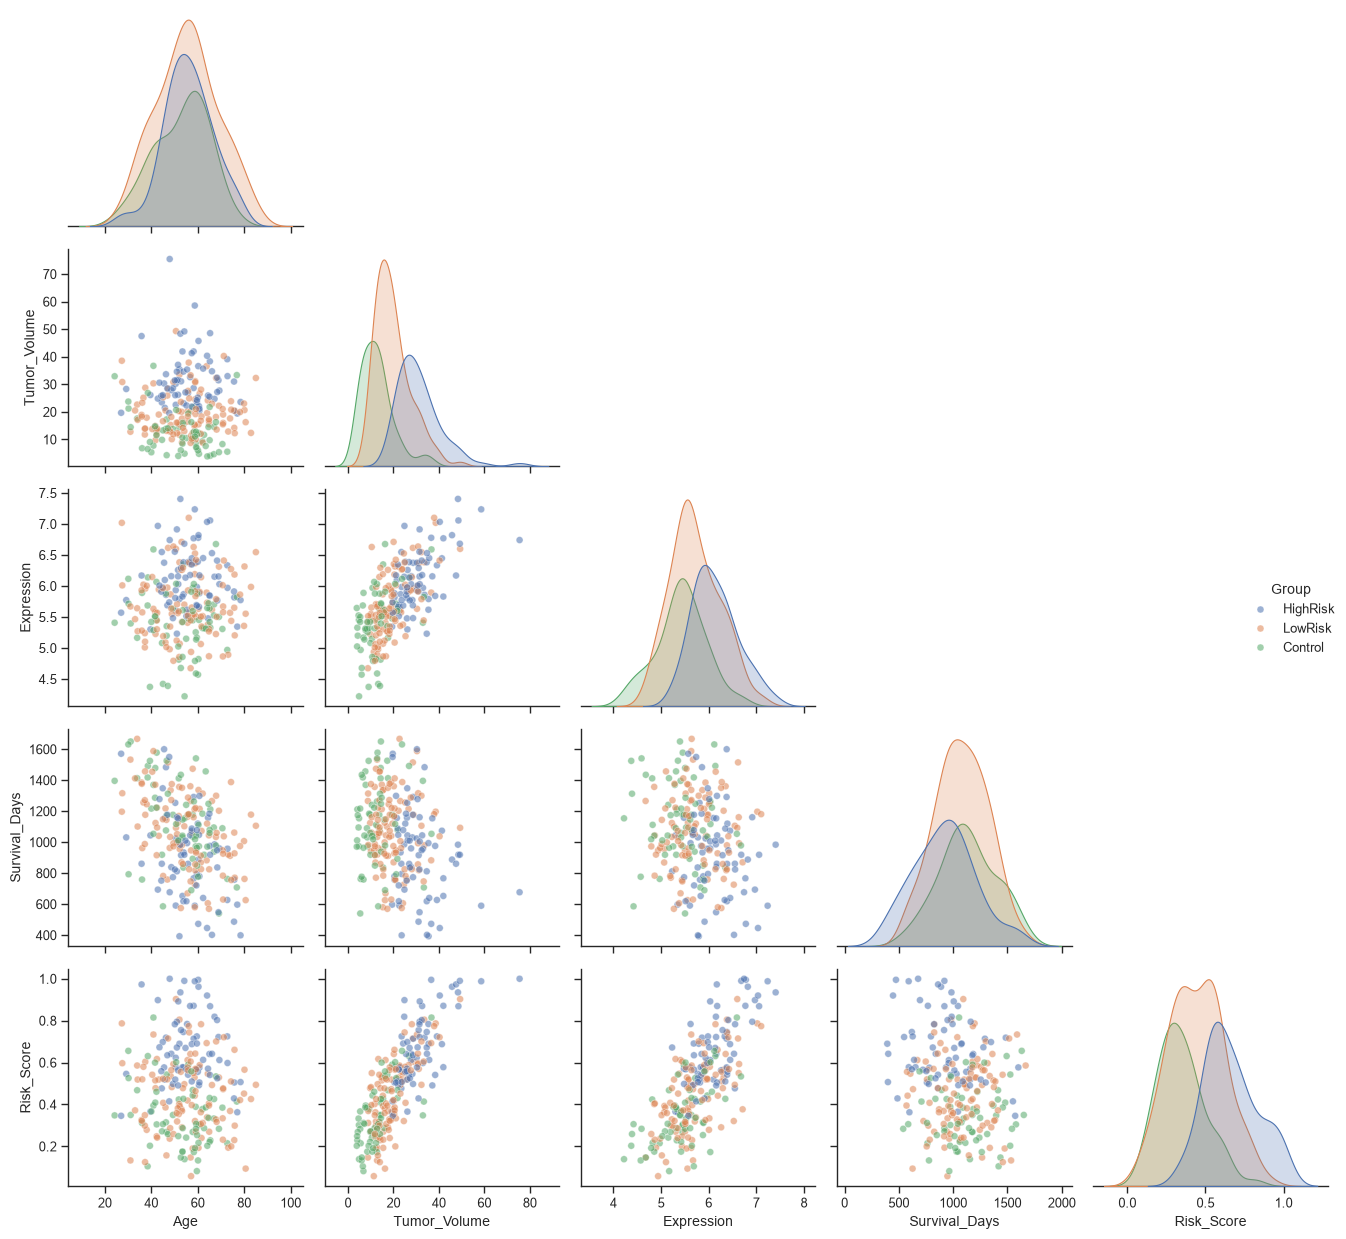

In [23]:
# Select a compact set of numeric research variables.
pair_data = clinical[["Age", "Tumor_Volume", "Expression", "Survival_Days", "Risk_Score", "Group"]]

# Create a pairwise relationship matrix.
# hue colors observations by clinical group.
g = sns.pairplot(
    pair_data,
    hue="Group",
    corner=True,
    plot_kws={"alpha": 0.55, "s": 25}
)

# Apply a compact layout to the pairwise matrix.
g.figure.tight_layout()

# Display the pairplot.
plt.show()


## 15. `PairGrid()` for full customization

`PairGrid` is the lower-level building block behind many pairwise visualization workflows. It allows you to assign different functions to the diagonal, lower triangle, and upper triangle.

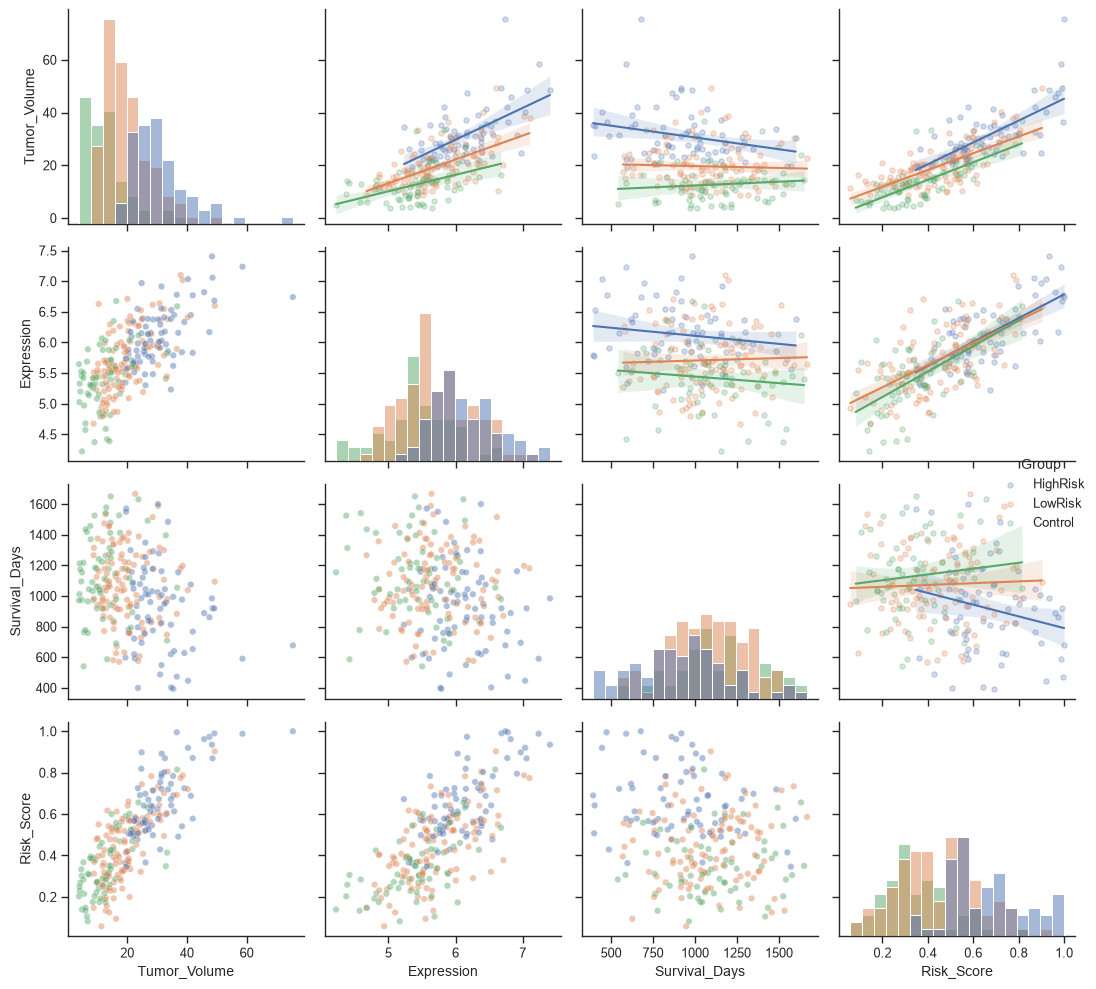

In [24]:
# Use a small subset of variables so the grid stays readable.
pair_subset = clinical[["Tumor_Volume", "Expression", "Survival_Days", "Risk_Score", "Group"]].copy()

# Build a custom PairGrid and color points by clinical group.
g = sns.PairGrid(
    pair_subset,
    hue="Group",
    corner=False
)

# Draw scatter plots in the lower triangle.
g.map_lower(sns.scatterplot, s=22, alpha=0.45)

# Draw regression-like relationship plots in the upper triangle.
g.map_upper(sns.regplot, scatter_kws={"s": 14, "alpha": 0.25}, line_kws={"linewidth": 1.5})

# Draw simple univariate histograms on the diagonal.
g.map_diag(sns.histplot, bins=18, color="steelblue")

# Add a legend for the group colors.
g.add_legend()

# Compact the full grid.
g.figure.tight_layout()

# Display the grid.
plt.show()


## 16. `FacetGrid()` for controlled faceting

`FacetGrid` is ideal when you want to repeat a plotting function across combinations of categorical variables.

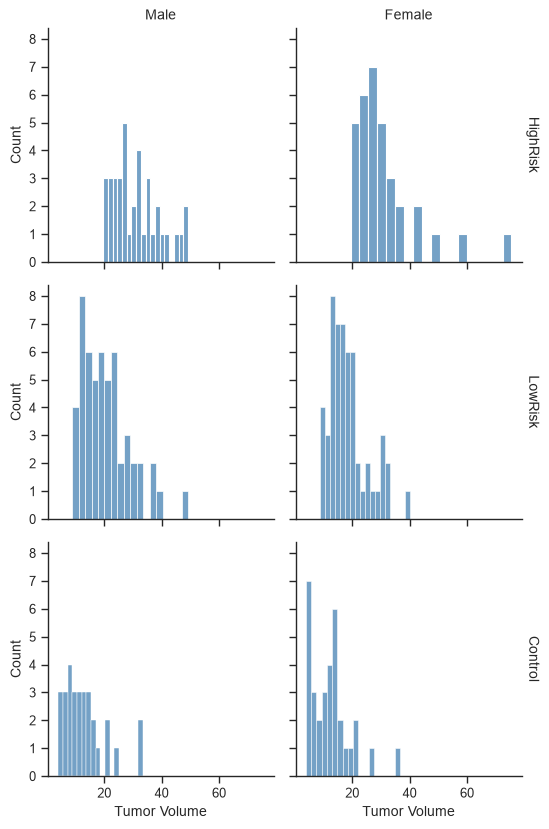

In [25]:
# Create a faceting grid with one panel per sex and row per clinical group.
g = sns.FacetGrid(
    clinical,
    row="Group",
    col="Sex",
    height=2.8,
    margin_titles=True
)

# Map a histogram onto each facet.
g.map_dataframe(sns.histplot, x="Tumor_Volume", bins=18, color="steelblue")

# Add readable axis labels and panel titles.
g.set_axis_labels("Tumor Volume", "Count")
g.set_titles(row_template="{row_name}", col_template="{col_name}")

# Apply tight spacing to the full grid.
g.figure.tight_layout()

# Display the figure.
plt.show()


## 17. Matrix visualization — `heatmap()`

Heatmaps are central to Bioinformatics and clinical ML for displaying:

- correlation matrices
- gene-expression matrices
- model performance matrices
- feature relationships

Official Seaborn example: **Annotated heatmaps**
https://seaborn.pydata.org/examples/spreadsheet_heatmap.html

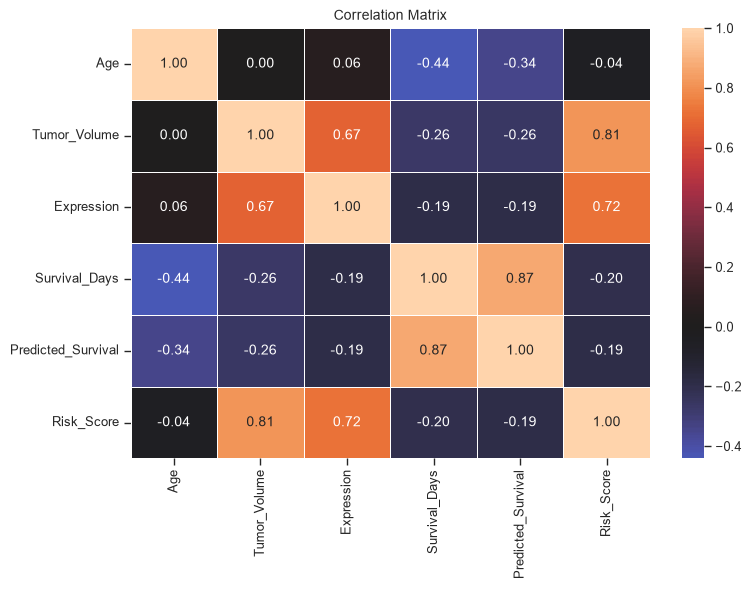

In [26]:
# Select numeric research variables for correlation analysis.
corr = clinical[["Age", "Tumor_Volume", "Expression", "Survival_Days", "Predicted_Survival", "Risk_Score"]].corr()

# Create the figure and axes.
fig, ax = plt.subplots(figsize=(8, 6))

# Draw the correlation matrix as a color-coded heatmap.
# annot=True writes the correlation coefficient into each cell.
# fmt formats the displayed values to two decimal places.
# center=0 makes zero the visual midpoint of the diverging scale.
# linewidths adds separation between cells.
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    center=0,
    linewidths=0.5,
    ax=ax
)

# Give the heatmap a descriptive title.
ax.set_title("Correlation Matrix")

# Tighten the layout.
plt.tight_layout()

# Display the figure.
plt.show()


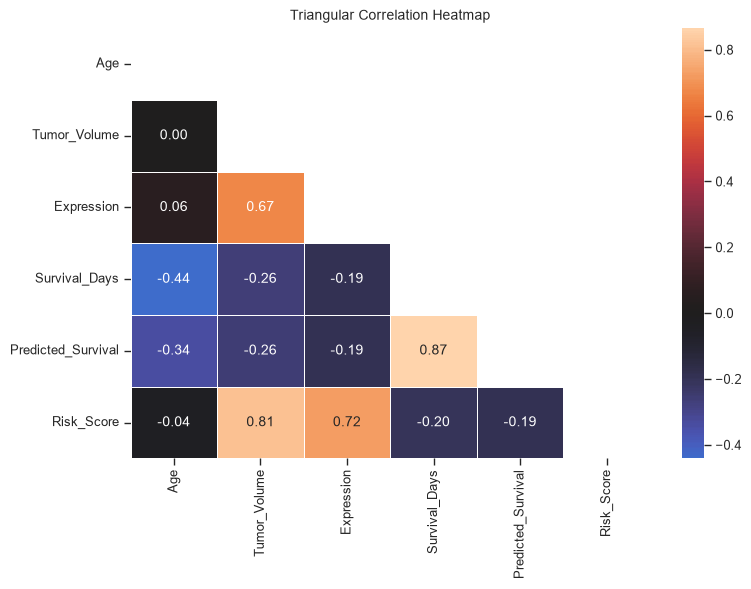

In [27]:
# Create a triangular mask so the correlation matrix is not shown twice.
mask = np.triu(np.ones_like(corr, dtype=bool))

# Create the figure and axes.
fig, ax = plt.subplots(figsize=(8, 6))

# Draw only the lower triangle of the correlation matrix.
# mask hides redundant upper-triangle values.
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    center=0,
    linewidths=0.5,
    ax=ax
)

# Add a concise title.
ax.set_title("Triangular Correlation Heatmap")

# Adjust the layout.
plt.tight_layout()

# Display the figure.
plt.show()


### How to read a correlation heatmap

Correlation coefficients range from negative to positive association. A heatmap helps identify patterns quickly, but correlation is not evidence of causation and does not replace an appropriate statistical model.

## 18. Bioinformatics: gene-expression heatmap

A classic research figure is a feature-by-sample heatmap. In real projects, the values might represent normalized expression, pathway scores, methylation measures, or other molecular features.

This notebook creates a synthetic expression matrix to demonstrate the visualization only.

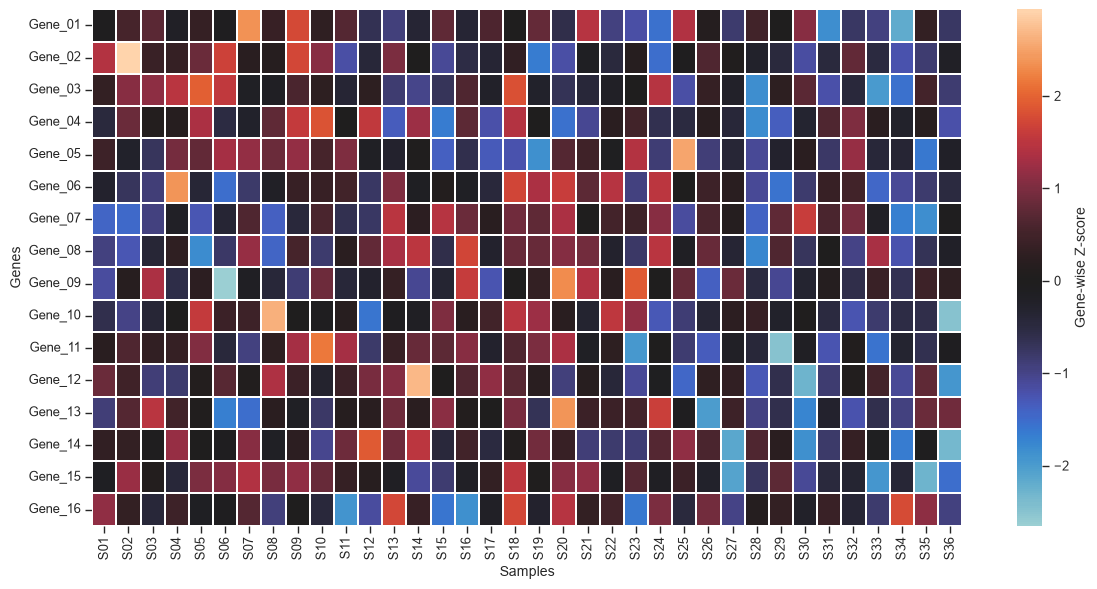

In [28]:
# Define synthetic gene names for the teaching example.
genes = [f"Gene_{i:02d}" for i in range(1, 17)]

# Create a synthetic gene-expression matrix for 36 samples.
expr = rng.normal(0, 1, size=(len(genes), 36))

# Add simple group-specific effects to a subset of genes for visualization.
expr[:5, :12] += 1.2
expr[5:10, 12:24] += 0.9
expr[10:15, 24:] -= 1.0

# Build the expression DataFrame and standardize each gene for a heatmap.
expr_df = pd.DataFrame(expr, index=genes, columns=[f"S{i:02d}" for i in range(1, 37)])
expr_z = expr_df.sub(expr_df.mean(axis=1), axis=0).div(expr_df.std(axis=1), axis=0)

# Create the figure and axes.
fig, ax = plt.subplots(figsize=(12, 6))

# Draw the standardized expression values as a heatmap.
# center=0 makes zero expression shift the visual midpoint.
# cbar_kws controls the colorbar label.
sns.heatmap(
    expr_z,
    center=0,
    linewidths=0.2,
    cbar_kws={"label": "Gene-wise Z-score"},
    ax=ax
)

# Label the two dimensions of the molecular matrix.
ax.set_xlabel("Samples")
ax.set_ylabel("Genes")

# Keep the figure compact and readable.
plt.tight_layout()

# Display the heatmap.
plt.show()


### How to read a gene-expression heatmap

Rows represent genes and columns represent samples. Standardization makes relative high/low expression patterns easier to compare across genes. Real analyses require an appropriate normalization strategy before visualization.

## 19. Hierarchical structure — `clustermap()`

`clustermap()` combines a heatmap with hierarchical clustering. It can reveal groups of similar samples or features.

Official gallery model: **Discovering structure in heatmap data**
https://seaborn.pydata.org/examples/structured_heatmap.html

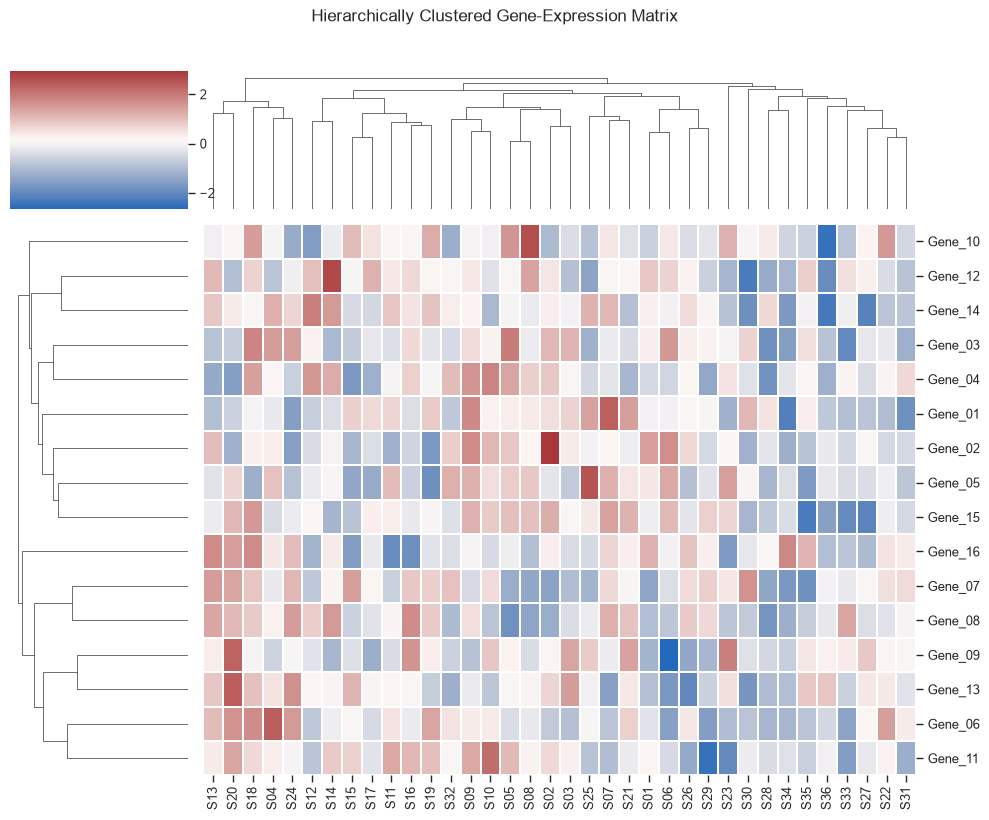

In [29]:
# Create a compact clustered heatmap from the synthetic expression matrix.
# z_score=0 standardizes each row before clustering and drawing the matrix.
cluster = sns.clustermap(
    expr_df,
    z_score=0,
    cmap="vlag",
    figsize=(10, 8),
    linewidths=0.15
)

# Add an overall title with a small vertical offset.
cluster.fig.suptitle("Hierarchically Clustered Gene-Expression Matrix", y=1.02)

# Apply a compact layout.
cluster.fig.tight_layout()

# Display the clustered heatmap.
plt.show()


## 20. Publication-quality color systems

Good scientific color choices should communicate structure without creating unnecessary visual noise.

Useful Seaborn tools:

- `sns.color_palette()`
- sequential palettes for ordered magnitude
- diverging palettes for values around a meaningful midpoint
- categorical palettes for distinct groups

Official reference: https://seaborn.pydata.org/tutorial/color_palettes.html

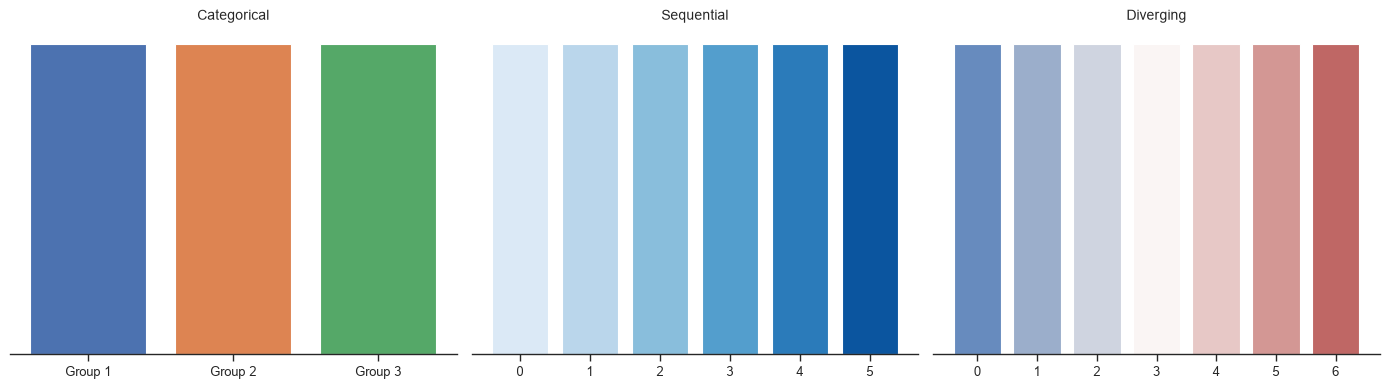

In [30]:
# Create the figure and axes.
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Create a categorical palette for distinct clinical groups.
categorical_palette = sns.color_palette("deep", 3)

# Create a sequential palette for values with an ordered magnitude.
sequential_palette = sns.color_palette("Blues", 6)

# Create a diverging palette for values around a meaningful center.
diverging_palette = sns.color_palette("vlag", 7)

# Display the categorical palette as simple bars.
axes[0].bar(range(3), [1, 1, 1], color=categorical_palette)
axes[0].set_title("Categorical")
axes[0].set_xticks(range(3), ["Group 1", "Group 2", "Group 3"])

# Display the sequential palette as ordered bars.
axes[1].bar(range(6), [1, 1, 1, 1, 1, 1], color=sequential_palette)
axes[1].set_title("Sequential")

# Display the diverging palette as centered bars.
axes[2].bar(range(7), [1, 1, 1, 1, 1, 1, 1], color=diverging_palette)
axes[2].set_title("Diverging")

# Hide y-axis ticks because these panels only demonstrate color structure.
for ax in axes:
    ax.set_yticks([])
    sns.despine(ax=ax, left=True)

# Adjust spacing across panels.
plt.tight_layout()

# Display the palette guide.
plt.show()


## 21. Missing-data visualization

Seaborn does not provide a dedicated missing-data matrix function, but a Boolean DataFrame can be visualized effectively with `heatmap()`.

This is a useful bridge between exploratory data analysis and research preprocessing.

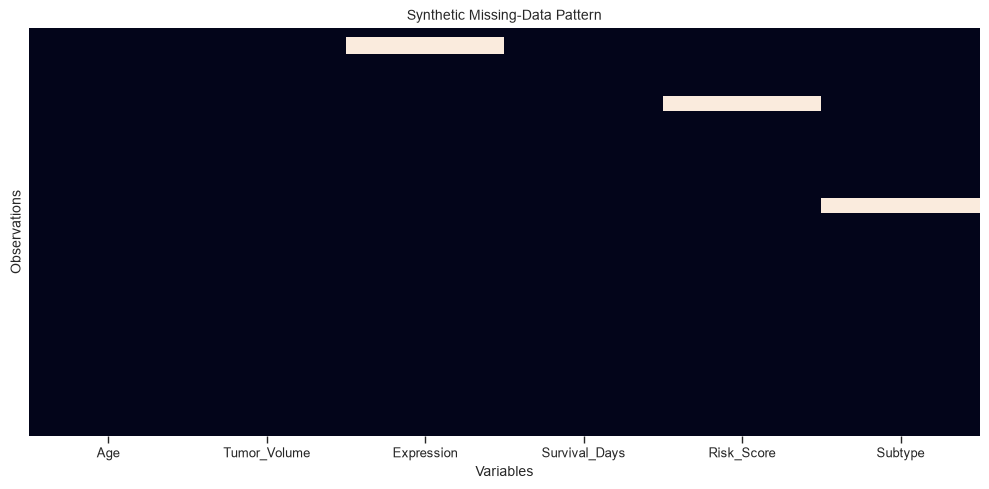

In [31]:
# Create a copy so the demonstration does not modify the main dataset.
clinical_missing = clinical[["Age", "Tumor_Volume", "Expression", "Survival_Days", "Risk_Score", "Subtype"]].copy()

# Introduce a small amount of synthetic missingness for teaching purposes.
clinical_missing.loc[5:14, "Expression"] = np.nan
clinical_missing.loc[40:48, "Risk_Score"] = np.nan
clinical_missing.loc[100:108, "Subtype"] = np.nan

# Convert the missingness pattern into True/False values.
missing_matrix = clinical_missing.isna()

# Create the figure and axes.
fig, ax = plt.subplots(figsize=(10, 5))

# Draw the missingness matrix.
# cbar=False removes the colorbar because the matrix is already binary.
sns.heatmap(
    missing_matrix,
    cbar=False,
    yticklabels=False,
    ax=ax
)

# Label the x-axis as variables.
ax.set_xlabel("Variables")
ax.set_ylabel("Observations")
ax.set_title("Synthetic Missing-Data Pattern")

# Adjust the layout.
plt.tight_layout()

# Display the figure.
plt.show()


## 22. Cancer AI: prediction vs actual

A central ML visualization is the comparison between a continuous model prediction and the observed target.

For survival models, the exact evaluation method depends on whether the task is ordinary regression, censored survival prediction, time-to-event modeling, or another formulation. The plot below is intentionally a simple regression-style teaching figure.

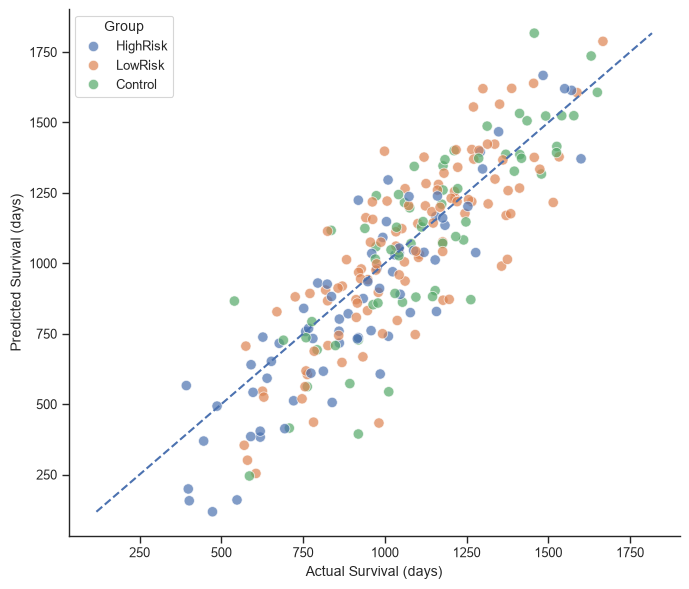

In [32]:
# Create the figure and axes.
fig, ax = plt.subplots(figsize=(7, 6))

# Plot actual survival against model-predicted survival.
# hue separates the synthetic clinical groups.
sns.scatterplot(
    data=clinical,
    x="Survival_Days",
    y="Predicted_Survival",
    hue="Group",
    s=55,
    alpha=0.7,
    ax=ax
)

# Find the shared axis limits so the reference line is square.
low = min(clinical["Survival_Days"].min(), clinical["Predicted_Survival"].min())
high = max(clinical["Survival_Days"].max(), clinical["Predicted_Survival"].max())

# Draw the ideal prediction line y=x.
ax.plot([low, high], [low, high], linestyle="--", linewidth=1.5)

# Label the axes.
ax.set_xlabel("Actual Survival (days)")
ax.set_ylabel("Predicted Survival (days)")

# Clean the frame.
sns.despine(ax=ax)

# Tighten the layout.
plt.tight_layout()

# Display the figure.
plt.show()


### How to read prediction-vs-actual plots

Points close to the diagonal indicate smaller prediction errors in this simple visualization. Systematic deviations, changing spread, or subgroup differences can motivate deeper error analysis.

## 23. ML model diagnostics: residuals

Residual visualization can reveal whether a model makes errors in a structured way across the prediction range.

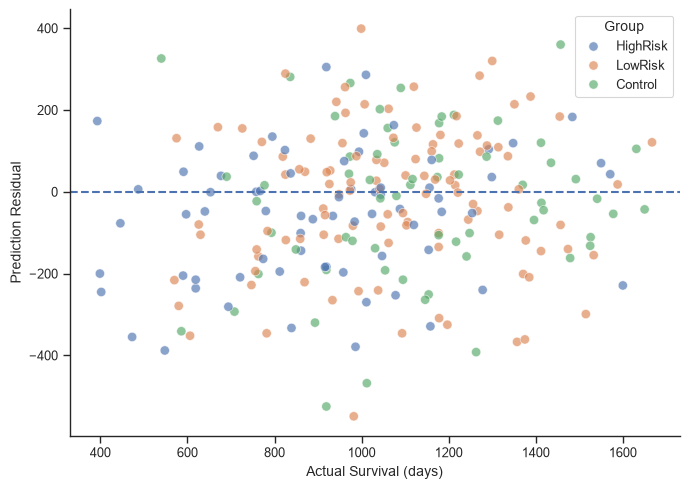

In [33]:
# Calculate the prediction residual for each observation.
clinical["Residual"] = clinical["Predicted_Survival"] - clinical["Survival_Days"]

# Create the figure and axes.
fig, ax = plt.subplots(figsize=(7, 5))

# Plot residuals against the observed survival target.
sns.scatterplot(
    data=clinical,
    x="Survival_Days",
    y="Residual",
    hue="Group",
    s=45,
    alpha=0.65,
    ax=ax
)

# Add a horizontal zero-error reference line.
ax.axhline(0, linestyle="--", linewidth=1.5)

# Label the axes.
ax.set_xlabel("Actual Survival (days)")
ax.set_ylabel("Prediction Residual")

# Remove unnecessary borders.
sns.despine(ax=ax)

# Adjust the layout.
plt.tight_layout()

# Display the residual figure.
plt.show()


## 24. Training curves for Cancer AI / Deep Learning

Seaborn can also produce polished training curves. The important principle is to keep **training and validation metrics clearly separated** and label the metric precisely.

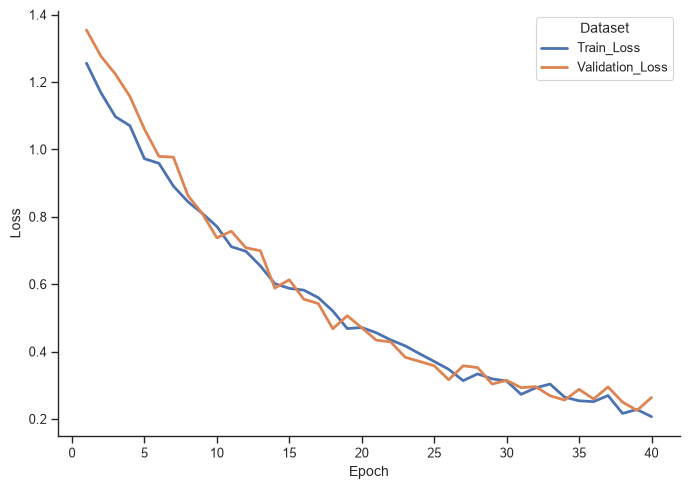

In [34]:
# Create a synthetic training-history DataFrame.
epochs = np.arange(1, 41)
train_loss = 1.20 * np.exp(-epochs / 16) + 0.12 + rng.normal(0, 0.015, len(epochs))
val_loss = 1.28 * np.exp(-epochs / 13) + 0.18 + rng.normal(0, 0.020, len(epochs))

training = pd.DataFrame({
    "Epoch": epochs,
    "Train_Loss": train_loss,
    "Validation_Loss": val_loss,
})

# Convert the training-history table from wide format to long format.
# Long-form data lets Seaborn map both curves using one lineplot call.
training_long = training.melt(
    id_vars="Epoch",
    var_name="Dataset",
    value_name="Loss"
)

# Create the figure and axes.
fig, ax = plt.subplots(figsize=(7, 5))

# Draw training and validation loss curves.
sns.lineplot(
    data=training_long,
    x="Epoch",
    y="Loss",
    hue="Dataset",
    linewidth=2,
    ax=ax
)

# Label the axes precisely.
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")

# Clean the frame.
sns.despine(ax=ax)

# Tighten the layout.
plt.tight_layout()

# Display the training curve.
plt.show()


### How to read training curves

The curves show how the selected metric changes over training iterations. A widening gap between training and validation behavior can be a useful warning sign for overfitting, but model diagnosis should also consider the validation design and dataset size.

## 25. Differential-expression-style volcano plot

A volcano plot is not a built-in Seaborn function. It is a research figure constructed from scatter plotting plus annotations.

Typical axes:

- x = log2 fold change
- y = -log10(p-value)

This example uses synthetic statistics solely to demonstrate figure construction.

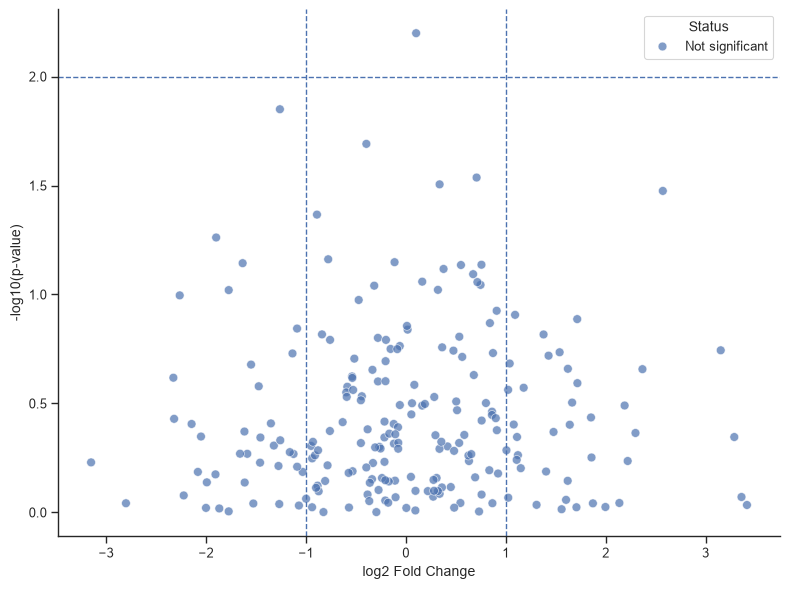

In [35]:
# Define the number of synthetic genes.
gene_n = 220

# Create synthetic gene names.
gene_names = np.array([f"GENE_{i:03d}" for i in range(1, gene_n + 1)])

# Generate synthetic log2 fold changes.
log2_fc = rng.normal(0, 1.2, gene_n)

# Generate synthetic p-values and convert them to a -log10 scale.
p_values = np.clip(rng.uniform(1e-6, 1, gene_n), 1e-6, 1)
neg_log10_p = -np.log10(p_values)

# Build a DataFrame containing the synthetic differential-expression values.
volcano = pd.DataFrame({
    "Gene": gene_names,
    "log2FC": log2_fc,
    "neg_log10_p": neg_log10_p,
})

# Define simple teaching thresholds for highlighting points.
volcano["Status"] = "Not significant"
volcano.loc[(volcano["log2FC"] > 1) & (volcano["neg_log10_p"] > 2), "Status"] = "Up"
volcano.loc[(volcano["log2FC"] < -1) & (volcano["neg_log10_p"] > 2), "Status"] = "Down"

# Create the figure and axes.
fig, ax = plt.subplots(figsize=(8, 6))

# Plot each synthetic gene as one point.
sns.scatterplot(
    data=volcano,
    x="log2FC",
    y="neg_log10_p",
    hue="Status",
    s=40,
    alpha=0.7,
    ax=ax
)

# Add vertical and horizontal reference thresholds.
ax.axvline(-1, linestyle="--", linewidth=1)
ax.axvline(1, linestyle="--", linewidth=1)
ax.axhline(2, linestyle="--", linewidth=1)

# Label the axes using the standard volcano-plot terminology.
ax.set_xlabel("log2 Fold Change")
ax.set_ylabel("-log10(p-value)")

# Clean the frame.
sns.despine(ax=ax)

# Tighten the layout.
plt.tight_layout()

# Display the volcano plot.
plt.show()


### Research note

Thresholds in real differential-expression analysis should be defined from the study design, multiple-testing procedure, effect-size criteria, and biological context. The thresholds above are teaching values, not a universal scientific rule.

## 26. Statistical annotations on a research figure

Sometimes a paper figure needs a p-value or test result. The important practice is to **compute the test separately**, then annotate the result with Matplotlib/Seaborn-compatible graphics.

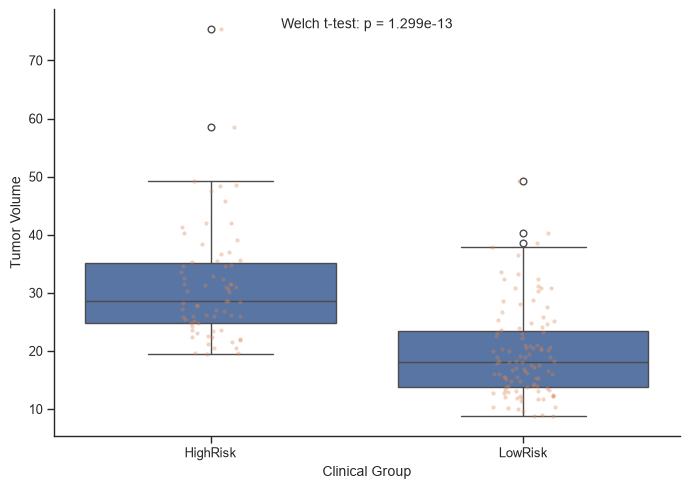

In [36]:
# Separate tumor-volume values by two synthetic clinical groups.
group_a = clinical.loc[clinical["Group"] == "LowRisk", "Tumor_Volume"]
group_b = clinical.loc[clinical["Group"] == "HighRisk", "Tumor_Volume"]

# Run a two-sided Welch t-test for this teaching example.
t_stat, p_value = stats.ttest_ind(group_a, group_b, equal_var=False)

# Create the figure and axes.
fig, ax = plt.subplots(figsize=(7, 5))

# Show the underlying distributions with a box plot.
sns.boxplot(
    data=clinical[clinical["Group"].isin(["LowRisk", "HighRisk"])],
    x="Group",
    y="Tumor_Volume",
    ax=ax
)

# Overlay raw observations to make sample size visible.
sns.stripplot(
    data=clinical[clinical["Group"].isin(["LowRisk", "HighRisk"])],
    x="Group",
    y="Tumor_Volume",
    size=3,
    alpha=0.35,
    ax=ax
)

# Place the test result in the figure as a text annotation.
ax.text(
    0.5,
    0.98,
    f"Welch t-test: p = {p_value:.3e}",
    transform=ax.transAxes,
    ha="center",
    va="top"
)

# Label the axes.
ax.set_xlabel("Clinical Group")
ax.set_ylabel("Tumor Volume")

# Clean the figure.
sns.despine(ax=ax)

# Tighten the layout.
plt.tight_layout()

# Display the figure.
plt.show()


## 27. Publication figure engineering: Matplotlib + Seaborn

Seaborn handles statistical plotting; Matplotlib gives detailed control over:

- figure size
- axes
- labels
- annotations
- panel letters
- ticks
- export settings

This combination is the practical pattern to use for scientific figures.

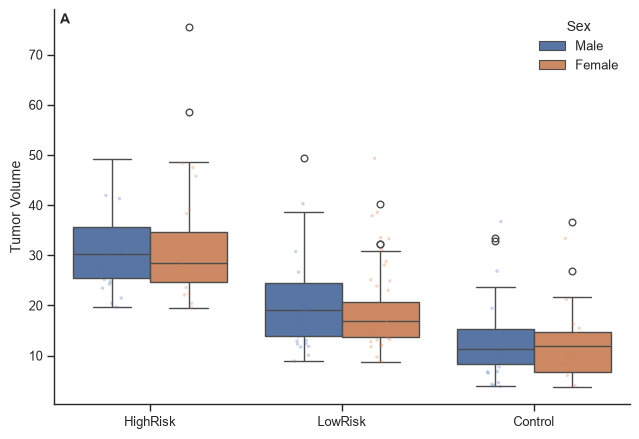

In [37]:
# Configure a publication-oriented theme before creating the figure.
sns.set_theme(style="ticks", context="paper", font_scale=1.05)

# Create a single publication-style figure.
fig, ax = plt.subplots(figsize=(6.5, 4.5))

# Plot tumor volume by clinical group and separate the distributions by sex.
sns.boxplot(
    data=clinical,
    x="Group",
    y="Tumor_Volume",
    hue="Sex",
    ax=ax
)

# Add a small number of raw observations on top of the summary plot.
sns.stripplot(
    data=clinical.sample(120, random_state=42),
    x="Group",
    y="Tumor_Volume",
    hue="Sex",
    dodge=True,
    alpha=0.3,
    size=2.5,
    legend=False,
    ax=ax
)

# Add a concise y-axis label suitable for a manuscript.
ax.set_xlabel("")
ax.set_ylabel("Tumor Volume")

# Add a panel label commonly used in multi-panel scientific figures.
ax.text(
    0.01,
    0.99,
    "A",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontweight="bold"
)

# Move the legend to a compact position.
sns.move_legend(ax, "upper right", frameon=False, title="Sex")

# Remove the top and right spines.
sns.despine(ax=ax)

# Prevent any clipping.
plt.tight_layout()

# Display the final publication-style figure.
plt.show()


## 28. Exporting figures for papers

For manuscripts, prefer vector formats such as PDF/SVG when appropriate. For raster requirements, export at a sufficiently high DPI.

Typical choices:

- PDF — vector figure for papers
- SVG — vector figure for editing/web workflows
- PNG — high-resolution raster

Always follow the target journal's author guidelines for dimensions, fonts, file type, and resolution.

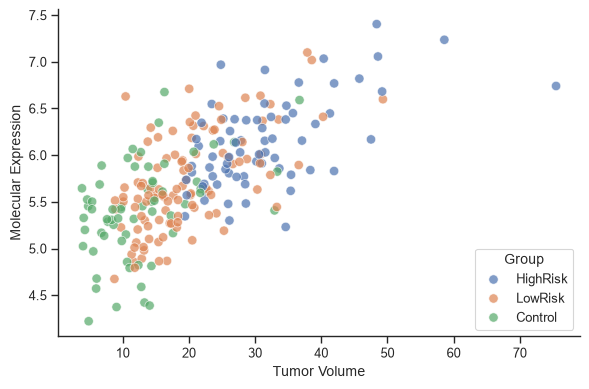

In [38]:
# Create a small example figure that can be exported.
fig, ax = plt.subplots(figsize=(6, 4))

# Draw a publication-style scatter plot.
sns.scatterplot(
    data=clinical,
    x="Tumor_Volume",
    y="Expression",
    hue="Group",
    s=45,
    alpha=0.7,
    ax=ax
)

# Add precise axis labels.
ax.set_xlabel("Tumor Volume")
ax.set_ylabel("Molecular Expression")

# Remove the unnecessary top and right spines.
sns.despine(ax=ax)

# Adjust the layout before exporting.
fig.tight_layout()

# Save a vector PDF version for a manuscript workflow.
fig.savefig("seaborn_research_figure.pdf", bbox_inches="tight")

# Save a high-resolution PNG version as a raster alternative.
fig.savefig("seaborn_research_figure.png", dpi=300, bbox_inches="tight")

# Display the figure in the notebook.
plt.show()


## 29. A reusable publication-quality template

Use this pattern as a starting point for future research figures. The exact plot, labels, uncertainty representation, colors, and statistical annotation should be adapted to the scientific question.

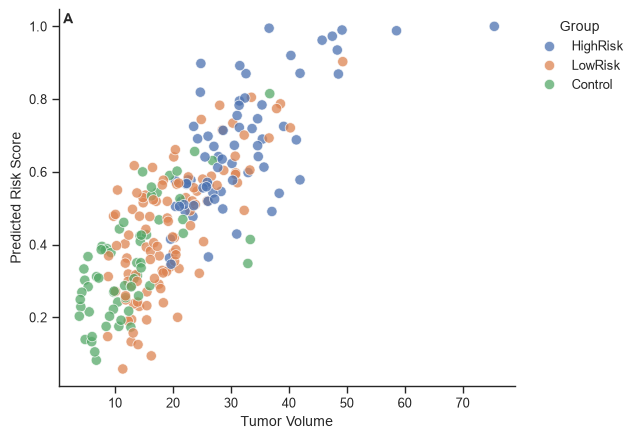

In [39]:
# Start from a consistent publication-oriented theme.
sns.set_theme(style="ticks", context="paper", font_scale=1.05)

# Create the figure and a single axes object.
fig, ax = plt.subplots(figsize=(6.5, 4.5))

# Draw the main plot.
sns.scatterplot(
    data=clinical,
    x="Tumor_Volume",
    y="Risk_Score",
    hue="Group",
    s=55,
    alpha=0.75,
    ax=ax
)

# Add descriptive axis labels.
ax.set_xlabel("Tumor Volume")
ax.set_ylabel("Predicted Risk Score")

# Add a concise panel label.
ax.text(0.01, 0.99, "A", transform=ax.transAxes, ha="left", va="top", fontweight="bold")

# Place the legend where it does not cover the central data area.
sns.move_legend(ax, "upper left", bbox_to_anchor=(1.02, 1), frameon=False, title="Group")

# Remove unnecessary borders.
sns.despine(ax=ax)

# Adjust the layout while reserving space for the legend.
fig.tight_layout()

# Display the reusable template.
plt.show()


## 30. Mini-project: clinical exploratory figure set

A compact research workflow can combine three complementary views:

1. distribution comparison
2. feature relationship
3. model prediction quality

The goal is not to make many figures; it is to answer distinct questions with appropriately chosen plots.

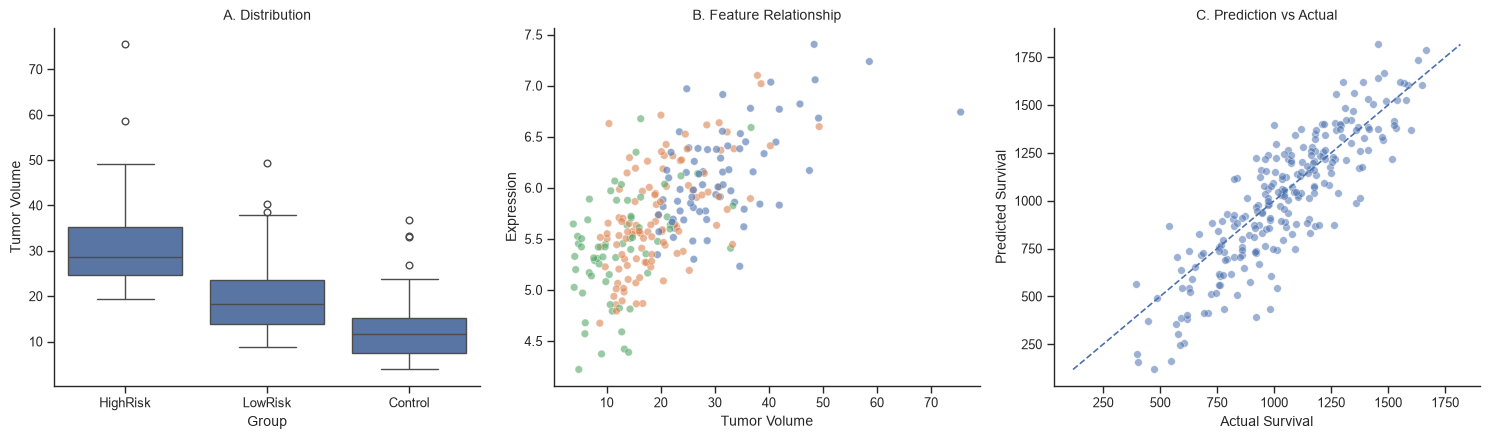

In [40]:
# Create a three-panel exploratory figure set.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Panel A: compare tumor-volume distributions across groups.
sns.boxplot(
    data=clinical,
    x="Group",
    y="Tumor_Volume",
    ax=axes[0]
)
axes[0].set_title("A. Distribution")
axes[0].set_xlabel("Group")
axes[0].set_ylabel("Tumor Volume")

# Panel B: inspect the relationship between tumor burden and expression.
sns.scatterplot(
    data=clinical,
    x="Tumor_Volume",
    y="Expression",
    hue="Group",
    s=30,
    alpha=0.6,
    legend=False,
    ax=axes[1]
)
axes[1].set_title("B. Feature Relationship")
axes[1].set_xlabel("Tumor Volume")
axes[1].set_ylabel("Expression")

# Panel C: compare actual and predicted survival.
sns.scatterplot(
    data=clinical,
    x="Survival_Days",
    y="Predicted_Survival",
    s=30,
    alpha=0.55,
    ax=axes[2]
)

# Draw the ideal prediction reference line.
low = min(clinical["Survival_Days"].min(), clinical["Predicted_Survival"].min())
high = max(clinical["Survival_Days"].max(), clinical["Predicted_Survival"].max())
axes[2].plot([low, high], [low, high], linestyle="--", linewidth=1.2)
axes[2].set_title("C. Prediction vs Actual")
axes[2].set_xlabel("Actual Survival")
axes[2].set_ylabel("Predicted Survival")

# Clean all panels consistently.
for ax in axes:
    sns.despine(ax=ax)

# Prevent labels and panel content from overlapping.
plt.tight_layout()

# Display the complete figure set.
plt.show()


## 31. Final checklist for research figures

### Before plotting
- Define the scientific question first.
- Decide whether the variable is continuous, categorical, longitudinal, or matrix-like.
- Check missing values and extreme observations.
- Confirm units and variable definitions.

### While plotting
- Use an appropriate graph for the question.
- Keep the x/y units explicit.
- Show raw observations when practical.
- Use uncertainty representations that match the analysis.
- Avoid excessive colors and decorative elements.

### Before publishing
- Verify statistical annotations independently.
- Use consistent fonts, sizes, and dimensions across figures.
- Confirm that labels remain readable after resizing.
- Export in the format requested by the journal.
- Make sure the figure caption explains the variables and statistical summaries.

> A publication-quality figure is not defined by appearance alone. It must also represent the underlying data and statistical analysis correctly.

## 32. Golden rules to remember

1. **Choose the plot from the research question, not from appearance.**
2. **Show the data structure clearly: distributions, relationships, groups, or matrices.**
3. **Use Seaborn for statistical plotting and Matplotlib for precise figure control.**
4. **Keep the code reproducible and the preprocessing explicit.**
5. **Use synthetic data for learning, and validate every research figure on the real study data.**
6. **For survival analysis, use a dedicated survival-analysis library/model when appropriate; Seaborn can visualize the resulting data but does not replace the survival model.**

## Official sources

- Seaborn Example Gallery: https://seaborn.pydata.org/examples/index.html
- Seaborn API Reference: https://seaborn.pydata.org/api.html
- Seaborn Documentation: https://seaborn.pydata.org/